# 1. Project Overview

### Books Sales Trend 

This project aims to study book data, including the number of reviews and the books that is listed as a bestseller, to uncover key trends such as the most in-demand genres and the factors that attract readers and increase a book’s popularity. This analysis is expected to provide valuable insights that can help publishers and authors enhance their marketing strategies and boost the success of their books. 

#### The analysis will focus on understanding:

- How do ratings and the number of reviews vary among bestsellers?
- Are certain authors more likely to have their books become bestsellers?
- Does the attractiveness of a book's cover influence its likelihood of becoming a bestseller?
- What genres are most represented among bestsellers?
- What is the relationship between price and bestseller books? , What is the price range of bestseller books?


This project is expected to contribute valuable insights to the publishing industry and help stakeholders make data-driven decisions.

# 2. Data Collecting

####  Data Collection Period: [30 Jan 2025] to [2 Feb 2025]


## Data sources

#### We collected our data by web scraping from the following online stores:

- **Amazon KSA Online Store:** A global platform with a wide range of books, including international bestsellers.

- **Jarir KSA Online Store:** A leading bookstore in Saudi Arabia, offering both Arabic and English books.

These sources were chosen because they represent a diverse range of books, have a large and diverse audience, and provide relatively complete data. By focusing on bestseller lists, we aim to study the factors that contribute to a book’s success in these markets.

## Data Description

To study the factors influencing bestseller books, we identified key attributes that are likely to have a significant impact on a book’s popularity. After reviewing related studies, research papers, and articles, we referenced the following sources to guide our attribute selection [1][2][3].

#### Based on these references, we selected the following attributes for our dataset:

- **Title:** The name of the book.

- **Price:** The retail price of the book.

- **Rating:** The average customer rating (e.g., out of 5 stars).

- **Num Of Reviews:** The total number of customer reviews.

- **Author:** The name of the author(s).

- **Book Type:** The format of the book (e.g., paperback, hardcover, eBook).

- **Genre:** The category or genre of the book (e.g., fiction, non-fiction, self-help).

- **Cover Image:** The image of the book cover (for visual analysis or reference).

These attributes were chosen because they are commonly associated with a book’s success and can help answer key questions.

## Challenges in Data Collection

 Data collection comes with various challenges that can hinder efficiency and accuracy. In our process, which involves web scraping, we faced several key difficulties:
1. **Time-Consuming Process:**
Data collection, especially when using web scraping techniques, requires significant time due to the complexity of extracting and processing data from multiple sources.

3. **Unclear HTML Structure:**
Some essential elements like <div> and <span> do not have clear or consistent class names, making it difficult to identify and extract the required data efficiently.

5. **Dynamic Content with JavaScript:**
Certain websites load content dynamically using JavaScript, which means that the data may not be visible in the initial HTML source code. This requires additional tools or techniques to handle dynamic content effectively.

6. **Request Limits and Access Restrictions:**
Some data sources impose strict limits on the number of requests that can be made within a specific timeframe, while others require special access permissions or API keys.

7. **Inconsistent Data Availability:**
Some information is available in certain sources but missing in others, leading to incomplete datasets and making it challenging to ensure data consistency and reliability.


## Actions Taken

1.  **Small-Scale Testing Before Full Collection:** We tested the scraping code on a small dataset to ensure accuracy. Once confirmed, we scaled up to collect the full dataset, avoiding repetitive work and saving time. 

2. **Relied on HTML Attributes and Structure:**
To handle unclear or inconsistent class names, we used element IDs or the DOM structure. For elements in arrays with the same class, we relied on their positional consistency to extract data.

3. **Used Selenium for Dynamic Content:**
For JavaScript-loaded content, we implemented Selenium to interact with pages like a browser, ensuring dynamic content was fully loaded before scraping. 

4. **Added Time Delays Between Requests:**
To avoid being blocked, we introduced time delays between requests to simulate natural user behavior, reducing the risk of triggering rate limits. 

5. **Leveraged Ready-Made Scraping Tools:**
Tools like Instant Data Scraper helped us gather initial data efficiently. We collected links to individual pages and accessed them separately to minimize request limits. 

6. **Combined Data from Multiple Sources:**
To address missing or inconsistent data, we merged datasets from different sources, ensuring a more comprehensive and reliable final dataset. 

7. **Conducted Manual Reviews and Validation:**
We manually reviewed samples of scraped data to identify and correct errors, ensuring high data quality and refining our scripts for better accuracy.

## Web Scraping


#### Web Scraping Tools used:
- Web scraper - free web scraping : https://chromewebstore.google.com/detail/web-scraper-free-web-scra/jnhgnonknehpejjnehehllkliplmbmhn?hl=en <br>
<b>Used when faced server blocking, in Amazon store <b>
- Instant Data Scraper - free web scraping  : https://chromewebstore.google.com/detail/instant-data-scraper/ofaokhiedipichpaobibbnahnkdoiiah <br>
<b>Used to extract bestseller books URLs from Jarir <b>

####  Libraries, Modules, and Methods Used in the Web Scraping Script
-  <b> Libraries Used:<b>
1. time → Standard Python library used to add delays between requests.
2. pandas → Handles CSV file operations (reading & saving scraped data).
3. requests → Fetches HTML content from web pages.
bs4 (BeautifulSoup) → Parses and extracts static HTML elements.
4. selenium → Automates browser interactions for scraping dynamically loaded content.
- <b> Modules Used (from Selenium): <b>
1. selenium.webdriver → Controls the Chrome browser for web scraping.
2. selenium.webdriver.common.by → Provides mechanisms to locate elements in the HTML (e.g., by class name, ID).
3. selenium.webdriver.support.ui → Contains WebDriverWait for handling dynamically loaded elements.
4. selenium.webdriver.support.expected_conditions (imported as EC) → Defines conditions for checking if elements are present before interacting with them.
 - <b> Methods Used: <b>
1. time.sleep(seconds) → Pauses execution to allow page elements to load.
2. requests.get(url, headers=HEADERS) → Sends an HTTP request to fetch page content.
3. BeautifulSoup(response.text, "html.parser") → Parses the HTML response for static content.
4. driver.get(url) → Loads a webpage using Selenium.
5. WebDriverWait(driver, timeout).until(condition) → Waits for a web element to appear before scraping.
6. EC.presence_of_element_located((By.CLASS_NAME, "tf-rating")) → Checks if an element is present in the DOM.
7. soup.find(tag, class_="class-name") → Finds the first occurrence of an element in the HTML.
8. soup.find_all(tag, class_="class-name") → Finds all matching elements.


### Amazom bestseller books 

#### We have decided to collect data from Amazon's bestseller Books by applying web scraping for two pages ( each one contain around 50 books )

In [2]:
import requests # used to send HTTP requests to web servers
from bs4 import BeautifulSoup # parsing HTML and XML documents
import pandas as pd # powerful data manipulation and analysis library
import numpy as np # used for numerical computations in Python


In [47]:
no_pages = 2
def get_data(pageNo):
    headers = {"User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:66.0) Gecko/20100101 Firefox/66.0", 
               "Accept-Encoding":"gzip, deflate", 
               "Accept":"text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", 
               "DNT":"1", "Connection":"close", 
               "Upgrade-Insecure-Requests":"1"}

    r = requests.get(f'https://www.amazon.sa/-/en/gp/bestsellers/books/ref=zg_bs_pg_1_books?ie=UTF8&pg={pageNo}&language=en&crid=1MSN01VVU9GYY&qid=1711400365&rnid=12463048031&sprefix=engl+book%2Cstripbooks%2C312&ref=sr_pg_{pageNo}', headers=headers)
    content = r.content
    soup = BeautifulSoup(content, "html.parser")

    alls = []
    for d in soup.findAll('div', attrs={'class':'zg-grid-general-faceout'}): 
        name = d.find('div', attrs={'class':'_cDEzb_p13n-sc-css-line-clamp-1_1Fn1y'})
        price = d.find('span', attrs={'class':'_cDEzb_p13n-sc-price_3mJ9Z'})
        rating = d.find('span', attrs={'class':'a-icon-alt'})
        users_rated = d.find('span', attrs={'aria-hidden':'true'})
        author = d.find('div', attrs={'class':'a-row'})
        format_type = d.find('span', attrs={'class':'a-text-normal'})
        genre = d.find('div', attrs={'class':'a-row a-size-base a-color-base'})
        cover_image = d.find('img', attrs={'class': 'a-dynamic-image p13n-sc-dynamic-image p13n-product-image'})

        all1 = []

        if name is not None:
            all1.append(name.text)
        else:
            all1.append("Null")

        if price is not None:
            all1.append(price.text)
        else:
            all1.append("Null")

        if rating is not None:
            all1.append(rating.text)
        else:
            all1.append("Null")

        if users_rated is not None:
            all1.append(users_rated.text)
        else:
            all1.append("Null")

        if author is not None:
            all1.append(author.text)
        else:
            all1.append("Null")

        if format_type is not None:
            all1.append(format_type.text)
        else:
            all1.append("Null")

        if genre is not None:
            all1.append(genre.text)
        else:
            all1.append("Null")

        if cover_image is not None:
            all1.append(cover_image['src'])
        else:
            all1.append("No Image")

        alls.append(all1)
    books = soup.findAll('div', attrs={'class': 'zg-grid-general-faceout'})
    print(f"Books found : {len(books)}")
    return alls



In [52]:
results = []
for i in range(1, no_pages+1):
    results.append(get_data(i))
flatten = lambda l: [item for sublist in l for item in sublist]
df = pd.DataFrame(flatten(results), columns=[
    'Title',          
    'Price',         
    'Rating',          
    'Num Of Reviews', 
    'Author',         
    'Book Type',      
    'Genre',     
    'Cover Image'     
])

Books found : 30
Books found : 30


<b>We notice here that only 30 books have been extacted from each page out of 50, could be due to server blocking. that's why we decided to collect other books using an extension for web scraping from google chrome.<b>

- Web scraper - free web scraping : https://chromewebstore.google.com/detail/web-scraper-free-web-scra/jnhgnonknehpejjnehehllkliplmbmhn?hl=en

In [54]:
# checking how it looks like 
df.head(10)

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image
0,كتاب التحصيلي علمي 46-47 (2025),SAR 98.00,4.3 out of 5 stars,10,Nasser bin Abdulaziz Al-Abdulkarim,Paperback,Null,https://images-eu.ssl-images-amazon.com/images...
1,El Sharq library المعاصر 9 تاسيس كمي 2/1 ورقي ...,SAR 107.58,4.5 out of 5 stars,230,عماد الجزيري,Paperback,Null,https://images-eu.ssl-images-amazon.com/images...
2,My First Library : Boxset Of 10 Board Books Fo...,SAR 59.00,4.6 out of 5 stars,"80,714",Wonder House Books,Board book,Null,https://images-eu.ssl-images-amazon.com/images...
3,فاتتني صلاة,SAR 26.00,4.7 out of 5 stars,301,اسلام جمال,Unknown Binding,Null,https://images-eu.ssl-images-amazon.com/images...
4,The Power of your Subconscious Mind,SAR 35.00,4.5 out of 5 stars,"14,131",Joseph Murphy,Paperback,Null,https://images-eu.ssl-images-amazon.com/images...
5,Coloriages mystères Disney Princesses: Colorie...,SAR 109.10,4.7 out of 5 stars,"5,880",Jérémy Mariez,Paperback,Null,https://images-eu.ssl-images-amazon.com/images...
6,101 Unicorn Colouring Book: Fun Activity Colou...,SAR 21.62,4.6 out of 5 stars,"2,321",Wonder House Books,Paperback,Null,https://images-eu.ssl-images-amazon.com/images...
7,White Nights,SAR 19.00,4.6 out of 5 stars,"1,583",Fyodor Dostoyevsky,Mass Market Paperback,Null,https://images-eu.ssl-images-amazon.com/images...
8,Null,SAR 65.00,4.7 out of 5 stars,"12,588","4.7 out of 5 stars 12,588",Paperback,Null,https://images-eu.ssl-images-amazon.com/images...
9,My First 365 Coloring Book: Jumbo Coloring Boo...,SAR 29.00,4.5 out of 5 stars,"1,625",Wonder House Books,Paperback,Null,https://images-eu.ssl-images-amazon.com/images...


<b>Note: since the genre column is inside each book's page, we had to collect them manually.<b>

*results might be diffrent since we have collected them few days ago and amazon's bestseller books might have changed a bit*

In [ ]:
# to save the data as a csv file
df.to_csv("amazon_raw_books.csv", index=False)

### Jarir bestseller books 

 * *We extrat Arabic and Engligh bestseller books URLs in Jarir (around 260 book) using **Instant Data Scraper** extention and save it in "jarir_bestsellers.csv" file to read it and make loop on it.*
*  Also we use **selenium** for javaScript dynamic elements like "Rating" and "Num Of Reviews".  

In [ ]:
import time
import pandas as pd
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


# CSV file containing book URLs
df = pd.read_csv("jarir_bestsellers.csv", names=["book_link"])

# CSV file containing book URLs
INPUT_CSV = "jarir_bestsellers.csv"
all_books_df = pd.DataFrame()

# Headers to mimic a browser request
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:122.0) Gecko/20100101 Firefox/122.0"
}

# Initialize Selenium WebDriver
driver = webdriver.Chrome()

def get_book_data(url):
    """Scrapes book data from Jarir's website."""
    book_details = {}

    # Scrape static content using Requests + BeautifulSoup
    response = requests.get(url, headers=HEADERS)
    response.encoding = "utf-8"  # Force UTF-8 encoding
    soup = BeautifulSoup(response.text, "html.parser")

    # Extract Title
    book_details["Title"] = soup.find("h2", class_="product-title__title").text.strip() if soup.find("h2", class_="product-title__title") else "Null"

    # Extract Price
    price_container = soup.find("span", class_="price_alignment")
    if price_container:
        value = price_container.find_all("span")[-1].text.strip() if price_container.find_all("span") else "Null"
        book_details["Price"] = value
    else:
        book_details["Price"] = "Null"

    # Use Selenium for dynamically loaded elements (Rating & Reviews)
    driver.get(url)
    time.sleep(3)  # Allow time for JavaScript to load

    # Extract Rating
    try:
        rating_element = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CLASS_NAME, "tf-rating"))
        )
        book_details["Rating"] = rating_element.text.strip()
    except:
        book_details["Rating"] = "Null"

    # Extract Number of Reviews
    try:
        num_reviews_element = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CLASS_NAME, "tf-count"))
        )
        book_details["Num Of Reviews"] = num_reviews_element.text.strip()
    except:
        book_details["Num Of Reviews"] = "Null"

    # Extract Author
    author_tag = soup.find("b", string="Author:")
    book_details["Author"] = author_tag.find_next("span", class_="cl-blue").text.strip() if author_tag else "Null"

    # Extract Book Type (Format)
    format_tag = soup.find("b", string="Format:")
    book_details["Book Type"] = format_tag.find_next("span").text.strip() if format_tag else "Null"

    # Extract Genre (Book Classification)
    book_classification = soup.find("b", string="Book classification:")
    if book_classification:
        genres = [span.text.strip() for span in book_classification.find_next("span").find_all("span", class_="cl-blue") if span.text.strip()]
        book_details["Genre"] = ", ".join(genres) if genres else "Null"
    else:
        book_details["Genre"] = "Null"

    # Extract High-Quality Cover Image
    image_tags = soup.find_all("img", class_="image image--contain")
    if len(image_tags) > 1:
        raw_image_url = image_tags[1]["src"]
        # Modify the URL to get better quality (replace width=54 with width=350)
        book_details["Cover Image"] = raw_image_url.replace("width=54", "width=350")
    else:
        book_details["Cover Image"] = "No Image"

    return book_details


# Read URLs from CSV & Scrape Data
i=1
df = pd.read_csv(INPUT_CSV, names=["book_link"], encoding="utf-8") 
for url in df["book_link"].dropna():  # Drop NaN values
    print(i, f"Scraping: {url}")
    book_info = get_book_data(url)
    i+=1

    # Append the scraped data to the DataFrame
    all_books_df = pd.concat([all_books_df, pd.DataFrame([book_info])], ignore_index=True)
    time.sleep(3)  # Delay to prevent request blocking

# Close Selenium WebDriver
driver.quit()

# Drop the URL column (not needed in final output)
all_books_df.drop(columns=["URL"], inplace=True, errors="ignore")



In [ ]:
all_books_df.to_csv("jarir_raw_books.csv", index=False)

#### Note: 
We  found 10 books in Jarir with null "Rating" and "Num Of Reviews" despite having actual values. These were manually corrected in the CSV file. Other nulls were confirmed to represent zero, as they appeared at the end of the bestseller list. The 10 books, however, were in the first half, surrounded by complete data, justifying manual updates..

# 3. Data Cleaning and Preprocessing (Prior EDA)

After examining the data, it is clear that some preprocessing and cleaning are needed to make it easier to use, interpret, process, and analyze.

We will apply several preprocessing techniques such as normalization, discretization, and other techniques as needed, which will be detailed below .

In [1]:
import pandas as pd
import re
df_jarir = pd.read_csv("jarir_raw_books.csv", encoding="utf-8")
df_amazon = pd.read_csv("amazon_raw_books.csv", encoding="utf-8")

### Check Missing Values

- In our data, some 'Author' values on Jarir dataset are represented as 'n/a', which contain hidden characters. In this code, we want to find these hidden patterns to handle them properly during the preprocessing steps.

In [2]:
# Display the content of row 34 only with hidden characters
df_jarir.loc[34, 'Author'].__repr__()

"'\\u200en\\u200e/\\u200ea\\u200e'"

In [3]:
def clean_hidden_pattern(df):
    pattern = '\u200en\u200e/\u200ea\u200e'
    for col in df.columns:
        df[col] = df[col].apply(
            lambda x: 'Unknown' if isinstance(x, str) and pattern in x else x
        )
    return df

# Apply to both DataFrames
df_jarir = clean_hidden_pattern(df_jarir)
df_amazon = clean_hidden_pattern(df_amazon)

In [4]:
def check_missing_values(df, df_name):
    # Find rows containing "Null", "Unknown", or NaN
    missing_rows = df[(df == 'Null').any(axis=1) | 
                      (df == 'Unknown').any(axis=1) | 
                      (df.isna()).any(axis=1)]
    
    missing_counts = ((df == 'Null') | (df == 'Unknown')).sum() + df.isna().sum()
    
    print(f"\n Missing values in {df_name}:")
    print(missing_counts)
    
    return missing_rows 

# Apply to both DataFrames
missing_jarir = check_missing_values(df_jarir, "df_jarir")
missing_amazon = check_missing_values(df_amazon, "df_amazon")


 Missing values in df_jarir:
Title               0
Price               0
Rating            115
Num Of Reviews    115
Author             15
Book Type           0
Genre               0
Cover Image         0
dtype: int64

 Missing values in df_amazon:
Title             0
Price             0
Rating            1
Num Of Reviews    1
Author            1
Book Type         0
Genre             0
Cover Image       0
dtype: int64


In [5]:
print("Rows with 'Null', 'Unknown', or empty (NaN) values in Jarir dataset:")
missing_jarir

Rows with 'Null', 'Unknown', or empty (NaN) values in Jarir dataset:


,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image
34,365 قصة عن الاخلاق عبرة في كل يوم تبعدك عن الم...,68,4.7,(3 reviews),Unknown,غلاف مقوى,"Jarir Publications Books,, Audio & Video CD/DV...",https://www.jarir.com/cdn-cgi/image/fit=contai...
50,حكايات الاحلام السعيدة كنز من حكايات الاطفال,49,5,(2 reviews),Unknown,غلاف مقوى,"Jarir Publications Books,, Children Books,",https://www.jarir.com/cdn-cgi/image/fit=contai...
89,كنز الاطفال مجموعة من الحكايات الرائعة,49,5,(1 review),Unknown,غلاف مقوى,"Jarir Publications Books,, Children Books,",https://www.jarir.com/cdn-cgi/image/fit=contai...
90,مكتبة الطفل الاولى الحيوانات,39,5,(1 review),Unknown,كتاب مقوى,"Jarir Publications Books,, Children Books,, Be...",https://www.jarir.com/cdn-cgi/image/fit=contai...
91,مكتبة الطفل الاولى جسمي,39,5,(1 review),Unknown,كتاب مقوى,"Jarir Publications Books,, Children Books,, Be...",https://www.jarir.com/cdn-cgi/image/fit=contai...
...,...,...,...,...,...,...,...,...
255,Emily Wilde's Encyclopaedia of Faeries,49,Null,Null,Heather Fawcett,Paperback,"Fiction & Literature,, New Arrivals,, Best Sel...",https://www.jarir.com/cdn-cgi/image/fit=contai...
256,The Coworker - You See Her Everyday,59,Null,Null,Freida McFadden,Paperback,"Fiction & Literature,, Best Sellers,",https://www.jarir.com/cdn-cgi/image/fit=contai...
257,Psychology of Money - Timeless Lesson on Wealth,79,Null,Null,Morgan Housel,Paperback,"Business & Management,, Best Sellers",https://www.jarir.com/cdn-cgi/image/fit=contai...
259,Rich Dad Poor Dad,49,Null,Null,Robert Kiyosaki,Paperback,"Business & Management,, Best Sellers,",https://www.jarir.com/cdn-cgi/image/fit=contai...


In [6]:
print("Rows with 'Null', 'Unknown', or empty (NaN) values in Amazon dataset:")
missing_amazon

Rows with 'Null', 'Unknown', or empty (NaN) values in Amazon dataset:


,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image
7,مذكرات أخصائي نفسي - نورة محمد الكيال,SARآ 80.50,NaN,NaN,نورة محمد الكيال,Paperback,Psychology & Counseling,https://images-eu.ssl-images-amazon.com/images...
22,The Mountain Is You: Transforming Self-Sabotag...,SARآ 65.00,4.7 out of 5 stars,"12,555",NaN,Paperback,Motivational Self-Help,https://images-eu.ssl-images-amazon.com/images...


### Handling Missing Values

In [7]:
def clean_dataframe(df, df_name):

    df['Rating'] = df['Rating'].replace('Null', float('nan')).fillna(0)
    df['Num Of Reviews'] = df['Num Of Reviews'].replace('Null', float('nan')).fillna(0)

    df = df.dropna(subset=['Author'])

    print(f" {df_name} after cleaning:")
    print(df[['Rating', 'Num Of Reviews', 'Author']].head())

    return df

# Apply cleaning function to both dataframes
df_jarir = clean_dataframe(df_jarir, "df_jarir")
df_amazon = clean_dataframe(df_amazon, "df_amazon")

 df_jarir after cleaning:
  Rating Num Of Reviews              Author
0      5   (73 reviews)       ‎وليد العنزي‎
1    4.5   (37 reviews)     ‎أدم جيه كيرتز‎
2    4.7   (29 reviews)      ‎عماد الجزيري‎
3      5   (24 reviews)  ‎روبرت تي كيوساكي‎
4      5   (20 reviews)         ‎ادهم فادي‎
 df_amazon after cleaning:
               Rating Num Of Reviews                              Author
0  4.3 out of 5 stars              8  Nasser bin Abdulaziz Al-Abdulkarim
1  4.5 out of 5 stars            218                        عماد الجزيري
2  4.7 out of 5 stars          2,603                       Jérémy Mariez
3  4.7 out of 5 stars          5,847                       Jérémy Mariez
4  4.6 out of 5 stars          1,618                  Wonder House Books



- In this section, we will handle missing values in three ways:

1. **Unknown Authors**: For rows where the author is listed as "Unknown", we will leave it as is. This is because it doesn't represent a truly missing value, but rather indicates that the website did not specify the author's name. Therefore, we will retain "Unknown" as it appears on the website.

2. **Ratings and Reviews**: Some ratings and reviews are represented as null because they have not been rated. We will replace these null values with zero, indicating that no ratings or reviews were provided.

3. **Missing Author Names**: For rows where the author name is null (completely missing), we will drop these entries from the dataset, as they lack essential information.



In [10]:
df_amazon

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image
0,كتاب التحصيلي علمي 46-47 (2025),SARآ 98.00,4.3 out of 5 stars,8,Nasser bin Abdulaziz Al-Abdulkarim,Paperback,Graduate School Test Guides,https://images-eu.ssl-images-amazon.com/images...
1,El Sharq library المعاصر 9 تاسيس كمي 2/1 ورقي ...,SARآ 107.58,4.5 out of 5 stars,218,عماد الجزيري,Paperback,Graduate School Test Guides,https://images-eu.ssl-images-amazon.com/images...
2,Coloriages mystères Pixar,SARآ 109.10,4.7 out of 5 stars,"2,603",Jérémy Mariez,Paperback,Self-Help,https://images-eu.ssl-images-amazon.com/images...
3,Coloriages mystères Disney Princesses: Colorie...,SARآ 109.10,4.7 out of 5 stars,"5,847",Jérémy Mariez,Paperback,Sports & Outdoors,https://images-eu.ssl-images-amazon.com/images...
4,My First 365 Coloring Book: Jumbo Coloring Boo...,SARآ 29.00,4.6 out of 5 stars,"1,618",Wonder House Books,Paperback,Literature & Fiction for Children,https://images-eu.ssl-images-amazon.com/images...
...,...,...,...,...,...,...,...,...
75,Crime and Punishment,SAR49.00,4.6 out of 5 stars,"2,724",Fyodor Dostoyevsky,Paperback,Mysteries,https://images-eu.ssl-images-amazon.com/images...
76,The Ballad of Never After: the stunning sequel...,SAR54.00,4.8 out of 5 stars,"2,619",Stephanie Garber,Paperback,Romantic Fantasy,https://images-eu.ssl-images-amazon.com/images...
77,No Longer Human,SAR59.00,4.7 out of 5 stars,"13,656",Osamu Dazai,Paperback,Historical Fiction,https://images-eu.ssl-images-amazon.com/images...
78,"The Coming Wave: Technology, Power, and the Tw...",SAR62.00,4.4 out of 5 stars,884,Mustafa Suleyman,Paperback,Technology,https://images-eu.ssl-images-amazon.com/images...


In [11]:
df_jarir

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image
0,يقولون الاولين,58,5,(73 reviews),‎وليد العنزي‎,Paperback,"Fiction & Literature,, New Arrivals, Best Sell...",https://www.jarir.com/cdn-cgi/image/fit=contai...
1,صفحة واحدة في المرة رفيق مبدع يومي,59,4.5,(37 reviews),‎أدم جيه كيرتز‎,Paperback,"Jarir Publications Books,, Self Development,, ...",https://www.jarir.com/cdn-cgi/image/fit=contai...
2,المعاصر 9 تأسيس كمي ورقمي ومحوسب مع بنك المحوس...,120,4.7,(29 reviews),‎عماد الجزيري‎,Paperback,"School Textbooks,, New Arrivals, Best Sellers,",https://www.jarir.com/cdn-cgi/image/fit=contai...
3,الاب الغني الاب الفقير ما يعلمه الاثرياء ولا ي...,79,5,(24 reviews),‎روبرت تي كيوساكي‎,Paperback,"Jarir Publications Books,, Best Sellers,, Busi...",https://www.jarir.com/cdn-cgi/image/fit=contai...
4,مصحف القيام مقاس 25×35,89,5,(20 reviews),‎ادهم فادي‎,غلاف مقوى فني,"Islamic & Religion Books,, New Arrivals,, Best...",https://www.jarir.com/cdn-cgi/image/fit=contai...
...,...,...,...,...,...,...,...,...
256,The Coworker - You See Her Everyday,59,0,0,Freida McFadden,Paperback,"Fiction & Literature,, Best Sellers,",https://www.jarir.com/cdn-cgi/image/fit=contai...
257,Psychology of Money - Timeless Lesson on Wealth,79,0,0,Morgan Housel,Paperback,"Business & Management,, Best Sellers",https://www.jarir.com/cdn-cgi/image/fit=contai...
258,Dune,59,5,(1 review),Frank Herbert,Paperback,"Fiction & Literature,, Science Fiction,, Best ...",https://www.jarir.com/cdn-cgi/image/fit=contai...
259,Rich Dad Poor Dad,49,0,0,Robert Kiyosaki,Paperback,"Business & Management,, Best Sellers,",https://www.jarir.com/cdn-cgi/image/fit=contai...


### Handling Duplicate Rows 



In this section, we normalized the 'Title' column by converting the text to lowercase and removing extra spaces to standardize comparisons. Duplicate rows were identified based on the cleaned titles. We found that two books have the same title in jarir, one was **mistitled**, so we correct its title manually while the other was a diffrent book but have the same title. For Amazon, there were **no duplicates**.

In [12]:
import pandas as pd

def duplicate_dataframe(df, df_name):

    # Clean and normalize text in the 'Title' column (convert to lowercase and remove extra spaces)
    df['Title Clean'] = df['Title'].str.lower().str.strip()

    # Identify duplicate rows based on the cleaned 'Title' columns
    potential_duplicates = df[df.duplicated(subset=['Title Clean'], keep=False)]
    

    # Print duplicate rows to verify
    print(f"\033[1m{df_name} Duplicate rows:\033[0m")
    # 
    print(potential_duplicates)
    
    # Drop the 'Title Clean' column
    df.drop(columns='Title Clean', inplace=True)

# Apply cleaning function to both dataframes
duplicate_dataframe(df_jarir, "df_jarir")
duplicate_dataframe(df_amazon, "df_amazon")

# Handle dupilcated row manually 
df_jarir.at[59, 'Title'] = 'نادي الخامسة 5 صباحا'

# Updated DataFrame
print("\033[1m\nCheck Duplicate rows for Updated DataFrame:\033[0m")

# Check duplicate again
duplicate_dataframe(df_jarir, "df_jarir")

df_jarir Duplicate rows:
                             Title  Price Rating Num Of Reviews  \
16                    مميز بالاصفر     40    4.4   (14 reviews)   
59                    مميز بالاصفر     85      5    (2 reviews)   
69   الكتاب الكبير للانشطة الرائعة     69      5    (4 reviews)   
107  الكتاب الكبير للانشطة الرائعة     49      5     (1 review)   

                                           Author  Book Type  \
16   ‎روتشيل بنينتجون ‎/‎ اتش جاكسون براون الابن‎  Paperback   
59                                   ‎روبن شارما‎  غلاف مقوى   
69                          ‎سلسلة الكتاب الكبير‎  Paperback   
107                                       Unknown  غلاف مقوى   

                                                 Genre  \
16   Jarir Publications Books,, Best Sellers,, Self...   
59   Jarir Publications Books,, Best Sellers,, Self...   
69   Jarir Publications Books,, Audio & Video CD/DV...   
107  Jarir Publications Books,, Children Books,, Au...   

                           

### Cleaning and Formatting Numerical Columns


In [13]:
def clean_dataframe(df, df_name):

    df['Price'] = df['Price'].astype(str).str.extract(r'(\d+\.?\d*)')  # Extract numeric part from Price 
    df['Rating'] = df['Rating'].astype(str).str.extract(r'(\d+\.?\d*)')  # Extract numeric part from Rating
    df['Num Of Reviews'] = df['Num Of Reviews'].astype(str).str.replace(',', '', regex=True)  # remove commas from number
    df['Num Of Reviews'] = df['Num Of Reviews'].str.extract(r'(\d+)')

    df['Price'] = df['Price'].astype(float)
    df['Rating'] = df['Rating'].astype(float)
    df['Num Of Reviews'] = df['Num Of Reviews'].astype(int)

    print(f"\n {df_name} after cleaning:\n", df[['Price', 'Rating', 'Num Of Reviews']].head())
    return df

# Apply cleaning function to both dataframes
df_jarir = clean_dataframe(df_jarir, "df_jarir")
df_amazon = clean_dataframe(df_amazon, "df_amazon")



 df_jarir after cleaning:
    Price  Rating  Num Of Reviews
0   58.0     5.0              73
1   59.0     4.5              37
2  120.0     4.7              29
3   79.0     5.0              24
4   89.0     5.0              20

 df_amazon after cleaning:
     Price  Rating  Num Of Reviews
0   98.00     4.3               8
1  107.58     4.5             218
2  109.10     4.7            2603
3  109.10     4.7            5847
4   29.00     4.6            1618


- In this section, we cleaned and standardized three columns: `Price` , `Rating` , and `Num Of Reviews`. We used regular expressions to extract numeric values from these columns, ensuring only the relevant numbers were retained. After extraction, we converted `Price` and `Rating` to the float data type and `Num Of Reviews` to int, preparing the data for numerical analysis. This process ensured consistency and accuracy, making the dataset suitable for further analysis.

###  Language Unification


- In this section, we faced a problem with the `Author` column values. As you can see in our raw data, the names were mixed with Arabic and English. To standardize the language and make everything in English, we used Argostranslate. Below is the code we used to translate the `Author` column from Arabic to English

In [14]:
pip install argostranslate 

Note: you may need to restart the kernel to use updated packages.


In [15]:
import argostranslate.package
import argostranslate.translate

from_code = "ar"
to_code = "en"

argostranslate.package.update_package_index()
available_packages = argostranslate.package.get_available_packages()
package_to_install = next(
    filter(
        lambda x: x.from_code == from_code and x.to_code == to_code, available_packages
    )
)
argostranslate.package.install_from_path(package_to_install.download())

df_jarir['Author'] = df_jarir['Author'].apply(lambda x: argostranslate.translate.translate(x, from_code, to_code))
df_amazon['Author'] = df_amazon['Author'].apply(lambda x: argostranslate.translate.translate(x, from_code, to_code))

print("\ndf_jarir after translation:\n", df_jarir[['Author']].head())
print("\ndf_amazon after translation:\n", df_amazon[['Author']].head())


df_jarir after translation:
               Author
0     Walid Al-Anazi
1     Adam J. Kertz.
2      Imad Al-Zarri
3  Robert T. Kiusaki
4            Fatima.

df_amazon after translation:
                                Author
0  Nasser bin Abdulaziz Al-Abdulkarim
1                       Imad Al-Zarri
2                       Jérémy Mariez
3                       Jérémy Mariez
4                 Wonder House Book s


In [16]:
df_jarir

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image
0,يقولون الاولين,58.0,5.0,73,Walid Al-Anazi,Paperback,"Fiction & Literature,, New Arrivals, Best Sell...",https://www.jarir.com/cdn-cgi/image/fit=contai...
1,صفحة واحدة في المرة رفيق مبدع يومي,59.0,4.5,37,Adam J. Kertz.,Paperback,"Jarir Publications Books,, Self Development,, ...",https://www.jarir.com/cdn-cgi/image/fit=contai...
2,المعاصر 9 تأسيس كمي ورقمي ومحوسب مع بنك المحوس...,120.0,4.7,29,Imad Al-Zarri,Paperback,"School Textbooks,, New Arrivals, Best Sellers,",https://www.jarir.com/cdn-cgi/image/fit=contai...
3,الاب الغني الاب الفقير ما يعلمه الاثرياء ولا ي...,79.0,5.0,24,Robert T. Kiusaki,Paperback,"Jarir Publications Books,, Best Sellers,, Busi...",https://www.jarir.com/cdn-cgi/image/fit=contai...
4,مصحف القيام مقاس 25×35,89.0,5.0,20,Fatima.,غلاف مقوى فني,"Islamic & Religion Books,, New Arrivals,, Best...",https://www.jarir.com/cdn-cgi/image/fit=contai...
...,...,...,...,...,...,...,...,...
256,The Coworker - You See Her Everyday,59.0,0.0,0,Freida McFadden,Paperback,"Fiction & Literature,, Best Sellers,",https://www.jarir.com/cdn-cgi/image/fit=contai...
257,Psychology of Money - Timeless Lesson on Wealth,79.0,0.0,0,Morgan Housel,Paperback,"Business & Management,, Best Sellers",https://www.jarir.com/cdn-cgi/image/fit=contai...
258,Dune,59.0,5.0,1,Frank Herbe r t,Paperback,"Fiction & Literature,, Science Fiction,, Best ...",https://www.jarir.com/cdn-cgi/image/fit=contai...
259,Rich Dad Poor Dad,49.0,0.0,0,Robert Kiyosaki,Paperback,"Business & Management,, Best Sellers,",https://www.jarir.com/cdn-cgi/image/fit=contai...


In [17]:
df_amazon

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image
0,كتاب التحصيلي علمي 46-47 (2025),98.00,4.3,8,Nasser bin Abdulaziz Al-Abdulkarim,Paperback,Graduate School Test Guides,https://images-eu.ssl-images-amazon.com/images...
1,El Sharq library المعاصر 9 تاسيس كمي 2/1 ورقي ...,107.58,4.5,218,Imad Al-Zarri,Paperback,Graduate School Test Guides,https://images-eu.ssl-images-amazon.com/images...
2,Coloriages mystères Pixar,109.10,4.7,2603,Jérémy Mariez,Paperback,Self-Help,https://images-eu.ssl-images-amazon.com/images...
3,Coloriages mystères Disney Princesses: Colorie...,109.10,4.7,5847,Jérémy Mariez,Paperback,Sports & Outdoors,https://images-eu.ssl-images-amazon.com/images...
4,My First 365 Coloring Book: Jumbo Coloring Boo...,29.00,4.6,1618,Wonder House Book s,Paperback,Literature & Fiction for Children,https://images-eu.ssl-images-amazon.com/images...
...,...,...,...,...,...,...,...,...
75,Crime and Punishment,49.00,4.6,2724,Fyodor Dostoyevsky,Paperback,Mysteries,https://images-eu.ssl-images-amazon.com/images...
76,The Ballad of Never After: the stunning sequel...,54.00,4.8,2619,Stephanie Garbe r,Paperback,Romantic Fantasy,https://images-eu.ssl-images-amazon.com/images...
77,No Longer Human,59.00,4.7,13656,Osamu Dazai,Paperback,Historical Fiction,https://images-eu.ssl-images-amazon.com/images...
78,"The Coming Wave: Technology, Power, and the Tw...",62.00,4.4,884,Mustafa Suleyman,Paperback,Technology,https://images-eu.ssl-images-amazon.com/images...


### Genre Cleaning and Standardization


In [18]:
def clean_genre_column(df):
    df['Genre'] = df['Genre'].str.replace(',,', ',').str.strip()

    unnecessary_genres = ['Best Sellers', 'Jarir Publications Books', 'New Arrivals', 'Bargain Books', 'E-Books', 'Audio & Video CD/DVD']
    for unwanted in unnecessary_genres:
        df['Genre'] = df['Genre'].str.replace(f'{unwanted}, ', '', regex=False)
        df['Genre'] = df['Genre'].str.replace(f', {unwanted}', '', regex=False)
        df['Genre'] = df['Genre'].str.replace(unwanted, '', regex=False).str.replace(',,', ',').str.strip(', ')

    return df

df_jarir = clean_genre_column(df_jarir)
df_amazon = clean_genre_column(df_amazon)

genre_mapping = {
    'Fiction & Literature': 'Fiction Genres',
    'Literary Fiction': 'Fiction Genres',
    'Genre Fiction': 'Fiction Genres',
    'Mysteries': 'Mystery & Thriller',
    'Historical Mystery': 'Mystery & Thriller',
    'Psychological Thrillers': 'Mystery & Thriller',
    'Science Fiction': 'Fiction Genres',
    'Romantic Fantasy': 'Fiction Genres',
    'Psychological Fiction': 'Fiction Genres',
    'Comics & Graphic Novels': 'Comics & Humor',
    'Manga Comics & Graphic Novels': 'Comics & Humor',
    'Humor': 'Comics & Humor',
    'Humorous Fiction': 'Comics & Humor',
    'Self-Help': 'Self-Help & Personal Development',
    'Self Development': 'Self-Help & Personal Development',
    'Self-Esteem': 'Self-Help & Personal Development',
    'Motivational Self-Help': 'Self-Help & Personal Development',
    'Health': 'Health & Fitness',
    'Fitness & Dieting': 'Health & Fitness',
    'Diets': 'Health & Fitness',
    'Business & Management': 'Business & Finance',
    'Business Management': 'Business & Finance',
    'Finance': 'Business & Finance',
    'Forensic Psychology': 'Psychology & Philosophy',
    'Psychology & Counseling': 'Psychology & Philosophy',
    'Philosophy': 'Psychology & Philosophy',
    'Politics & Social Sciences': 'Politics & Social Sciences',
    'Graduate School Test Guides': 'Education & Reference',
    'School Textbooks': 'Education & Reference',
    'Higher & Continuing Education': 'Education & Reference',
    'Foreign Language Study & Reference': 'Education & Reference',
    'Textbooks and Study Guides': 'Education & Reference',
    'Technology': 'Technology & Digital Media',
    'Children\'s Early Learning Books on the Alphabet': 'Children & Young Adults',
    'Early Learning for Children': 'Children & Young Adults',
    'Explore the World Books for Children': 'Children & Young Adults',
    'Children Books': 'Children & Young Adults',
    'Education Studies & Teaching': 'Children & Young Adults',
    'Children\'s Books on Country & Farm Life': 'Children & Young Adults',
    'Children\'s Books on Family Life': 'Children & Young Adults',
    'Children\'s Books on Social Skills': 'Children & Young Adults',
    'Children\'s Books on Crafts & Hobbies': 'Children & Young Adults',
    'Literature & Fiction for Children': 'Children & Young Adults',
    'Fantasy for Young Adults': 'Children & Young Adults',
    'Mysteries & Thrillers for Young Adults': 'Children & Young Adults',
    'Digital Art': 'Arts, Crafts, & Hobbies',
    'Drawing': 'Arts, Crafts, & Hobbies',
    'Crafts': 'Arts, Crafts, & Hobbies',
    'Crafts & Hobbies': 'Arts, Crafts, & Hobbies',
    'Hobbies & Home': 'Arts, Crafts, & Hobbies',
    'Sports & Outdoors': 'Arts, Crafts, & Hobbies',
    'Islamic & Religion Books': 'Religion & Spirituality',
    'Islam': 'Religion & Spirituality',
    'History': 'History & Culture',
    'History & Geography': 'History & Culture',
    'Antiques & Collectibles': 'History & Culture',
    'Poetry & Literary Essays': 'Poetry & Essays',
    'Poetry Anthologies': 'Poetry & Essays',
    'Literary Essays & Correspondence': 'Poetry & Essays',
    'Family & Relationships': 'Parenting & Family',
    'Parenting & Family': 'Parenting & Family',
    'Cooking & Culinary Arts': 'Cookbooks & Food',
    'Celebrity & TV Show Cookbooks': 'Cookbooks & Food',
    'Baking': 'Cookbooks & Food',
}

def clean_genre_list(genre_str):
    if pd.isna(genre_str):  # Check if the value is NaN or None
        return None

    genres = [g.strip() for g in genre_str.split(',') if g.strip()]

    mapped_genres = set(genre_mapping.get(g, g) for g in genres)

    main_categories_priority = ['Fiction Genres', 'Non-Fiction Genres', 'Children & Young Adults', 'Arts, Crafts, & Hobbies',
                                'Religion & Spirituality', 'History & Culture', 'Poetry & Essays', 'Parenting & Family', 'Cookbooks & Food']
    for category in main_categories_priority:
        if category in mapped_genres:
            return category
    return ', '.join(mapped_genres) if mapped_genres else None

df_jarir['Genre'] = df_jarir['Genre'].apply(clean_genre_list)
df_amazon['Genre'] = df_amazon['Genre'].apply(clean_genre_list)

df_jarir.dropna(subset=['Genre'], inplace=True)
df_amazon.dropna(subset=['Genre'], inplace=True)
df_jarir.reset_index(drop=True, inplace=True)

# Display the cleaned DataFrame
#rawBooks_df.to_csv("working.csv", index=False)

- In this section, we focused on cleaning and standardizing the `Genre` column to ensure consistency and remove redundant or irrelevant entries. We started by eliminating duplicate commas and unnecessary whitespace. Then, we removed irrelevant values such as "Best Sellers" and "Audio & Video CD/DVD." Finally, we applied a mapping to unify similar genres under standardized names, for example, "Fiction & Literature" was categorized as "Fiction Genres." This step was crucial to maintain a consistent data structure and improve the quality of analysis based on genre classifications.

- In addition, we want to mention that we didn’t perform preprocessing on the `Book Type` column. Although we know it contains different languages and some issues, we decided not to spend time on it for now. If we later determine that it’s necessary, we will apply the proper preprocessing. Otherwise, we will drop the column

In [19]:
df_jarir.to_csv("Clean_Jarir.csv", index=False)

In [20]:
df_amazon.to_csv("Clean_Amazon.csv", index=False)

## Image Processing

### Downloading Book Cover Images Using Selenium

In [172]:
pip install webdriver-manager

Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import os
import time


jarir_file_path = "Clean_Jarir.csv"  # Ensure this file exists
amazon_file_path = "Clean_Amazon.csv"  # Ensure this file exists

df_jarir = pd.read_csv(jarir_file_path)
df_amazon = pd.read_csv(amazon_file_path)

df = pd.concat([df_jarir, df_amazon], ignore_index=True)

# Set up Selenium options
chrome_options = Options()
chrome_options.add_argument("--headless")  # Run in headless mode
chrome_options.add_argument("--disable-gpu")
chrome_options.add_argument("--no-sandbox")

# Start WebDriver
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

# Directory to save images
image_dir = "book_covers"
os.makedirs(image_dir, exist_ok=True)

# Number of images to download
num_images = 315  # Adjust as needed

# Extract image URLs from the "Cover Image" column
image_urls = df["Cover Image"].dropna().head(num_images).tolist()

# Download images using Selenium and save them directly
for idx, url in enumerate(image_urls):
    try:
        driver.get(url)
        time.sleep(3)  # Wait for the page to load
        
        # Locate the image element
        image_element = driver.find_element("tag name", "img")

        # Save the image via Selenium
        image_path = os.path.join(image_dir, f"book_{idx}.png")
        image_element.screenshot(image_path)

    except Exception as e :
        print(f"Error downloading image {idx}: {e}")  # Print the error message
        pass  # Ignore errors and continue

# Close the browser after completing the task
driver.quit()
print("Image download process completed.")

Image download process completed.


We used Selenium to automate the downloading of book cover images from Clean_Jarir.csv and Clean_Amazon.csv, overcoming website restrictions and dynamic loading by simulating real user interactions. Running Selenium in headless mode, we stored the images in the "book_covers" directory, extracting 315 URLs from the `Cover Image` column. For each image, we accessed the webpage, identified the `<img>` element, and captured a screenshot. Robust error handling ensured the process continued smoothly even if some images failed to load. With the book covers successfully downloaded, we can now proceed to analyze them for classification using color extraction, contrast measurement, edge complexity analysis, or machine learning techniques.

 ### Analyzing Images and Extracting Key Features

Now, we will load the downloaded images and extract the following visual features [4]:

- **Mean Color**: To determine the dominant colors in each cover by analyzing the average RGB values.
- **Contrast**: To measure how distinct the light and dark areas are, which affects readability and visual appeal.
- **Edge Complexity**: To assess the level of detail and design intricacy by detecting the number and density of edges.
- **Color Saturation**: To evaluate the intensity of colors, as more saturated colors tend to attract more attention.
- **Color Variance**: To determine the diversity of colors used in the cover, which contributes to its uniqueness and appeal.
- **Sharpness**: To measure the clarity of the image, as sharper images tend to appear more professional and visually striking.


In [31]:
import cv2
import numpy as np
import pandas as pd
import os

# Define the directory where book cover images are stored
image_dir = "book_covers"
image_files = [f for f in os.listdir(image_dir) if f.endswith(".png")]

# Function to extract visual features from images
def extract_visual_features(image_path):
    img = cv2.imread(image_path)
    
    if img is None:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan  # Return NaN if the image is not found

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Compute mean color (RGB channels separately)
    mean_red = np.mean(img[:, :, 0])
    mean_green = np.mean(img[:, :, 1])
    mean_blue = np.mean(img[:, :, 2])

    # Convert the image to grayscale for contrast analysis
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    contrast = np.std(gray_img)

    # Use edge detection to measure design complexity
    edges = cv2.Canny(gray_img, 100, 200)
    edge_complexity = np.mean(edges)

    # Compute color variance to measure color diversity
    color_variance = np.var(img)

    # Convert image to HSV and compute color saturation
    img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    saturation = np.mean(img_hsv[:, :, 1])  # Extract saturation channel

    # Compute sharpness using the Laplacian variance
    sharpness = cv2.Laplacian(gray_img, cv2.CV_64F).var()

    return mean_red, mean_green, mean_blue, contrast, edge_complexity, color_variance, saturation, sharpness

# Extract features from all images
features = []
for img_file in image_files:
    img_path = os.path.join(image_dir, img_file)
    mean_red, mean_green, mean_blue, contrast, edge_complexity, color_variance, saturation, sharpness = extract_visual_features(img_path)
    features.append((img_file, mean_red, mean_green, mean_blue, contrast, edge_complexity, color_variance, saturation, sharpness))

# Convert extracted features into a DataFrame
df_features = pd.DataFrame(features, columns=[
    "Filename", "Mean_Red", "Mean_Green", "Mean_Blue", "Contrast",
    "Edge_Complexity", "Color_Variance", "Color_Saturation", "Sharpness"
])

# Fill missing values (if any) with the mean of each numeric column
numeric_columns = df_features.select_dtypes(include=[np.number]).columns
df_features[numeric_columns] = df_features[numeric_columns].fillna(df_features[numeric_columns].mean())

# Save extracted features to a CSV file
output_file_path = "book_cover_features_extracted.csv"
df_features.to_csv(output_file_path, index=False)

print(f"Extracted features saved to: {output_file_path}")
print(df_features.head())  # Display the first few rows


Extracted features saved to: book_cover_features_extracted.csv
       Filename    Mean_Red  Mean_Green   Mean_Blue   Contrast  \
0    book_0.png  172.017045  156.053812  148.112580  78.277843   
1    book_1.png  243.930310  220.181714  124.435747  35.921744   
2   book_10.png  158.403151  167.478400  163.311559  85.002255   
3  book_100.png  178.144792  139.831445  173.488743  81.394792   
4  book_101.png  213.756465  214.630433  194.664033  57.967406   

   Edge_Complexity  Color_Variance  Color_Saturation   Sharpness  
0        12.693796     6369.722570         44.730751  423.469942  
1         8.447265     5995.211455        127.124098  845.075233  
2        17.435755     8609.745701         84.922220  966.692212  
3        15.614327     6164.745811        102.399918  511.562190  
4        14.436122     5538.794457         71.332073  327.691355  


### Classifying Covers as "Interesting" or "Not Interesting"

After extracting features, we will classify covers as "Interesting" if they exceed a threshold in contrast or edge complexity.

In [32]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the extracted features dataset
input_file_path = "book_cover_features_extracted.csv"
df_features = pd.read_csv(input_file_path)

# Selecting the relevant features for clustering
X = df_features[["Mean_Red", "Mean_Green", "Mean_Blue", "Contrast", "Edge_Complexity", "Color_Variance", "Color_Saturation", "Sharpness"]]

# Normalize the features to ensure equal weighting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means Clustering (2 clusters: Interesting / Not Interesting)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_features["Cluster"] = kmeans.fit_predict(X_scaled)

# Determine which cluster represents "Interesting" covers
cluster_means = df_features.groupby("Cluster")[X.columns].mean()
interesting_cluster = cluster_means.mean(axis=1).idxmax()

# Assign labels based on cluster grouping
df_features["Interesting"] = df_features["Cluster"].apply(lambda x: 1 if x == interesting_cluster else 0)

# Drop the Cluster column after classification
df_features.drop(columns=["Cluster"], inplace=True)

# Save the classification results to a new CSV file
output_file_path = "book_cover_features_with_classification.csv"
df_features.to_csv(output_file_path, index=False)

print(f"Book cover classification completed using K-Means. Results saved to: {output_file_path}")

# Display the first few rows of the classified data
print(df_features.head())


Book cover classification completed using K-Means. Results saved to: book_cover_features_with_classification.csv
       Filename    Mean_Red  Mean_Green   Mean_Blue   Contrast  \
0    book_0.png  172.017045  156.053812  148.112580  78.277843   
1    book_1.png  243.930310  220.181714  124.435747  35.921744   
2   book_10.png  158.403151  167.478400  163.311559  85.002255   
3  book_100.png  178.144792  139.831445  173.488743  81.394792   
4  book_101.png  213.756465  214.630433  194.664033  57.967406   

   Edge_Complexity  Color_Variance  Color_Saturation   Sharpness  Interesting  
0        12.693796     6369.722570         44.730751  423.469942            1  
1         8.447265     5995.211455        127.124098  845.075233            0  
2        17.435755     8609.745701         84.922220  966.692212            1  
3        15.614327     6164.745811        102.399918  511.562190            1  
4        14.436122     5538.794457         71.332073  327.691355            0  


In **this step**, we **prepared the extracted visual features** (such as contrast, edge complexity, and mean color) and then **applied the K-Means Clustering algorithm** to automatically classify book covers into two groups: **"Interesting" and "Not Interesting"**. First, we **normalized the features** using `StandardScaler()` to ensure all attributes had the same scale. Then, we used `KMeans(n_clusters=2)` to cluster the book covers based on their visual patterns. Finally, we **analyzed the average feature values within each cluster** to determine which group represented "Interesting" covers and labeled the data accordingly. 

### Merging Classification Results with Original Book Data

Finally, we will update processed_data.csv to include the new "Interesting or Not" classification.

In [42]:
import os
jarir_image = pd.read_csv("Clean_Jarir.csv")
amazon_image = pd.read_csv("Clean_Amazon.csv")
df_features = pd.read_csv("book_cover_features_with_classification.csv")

# Standardize 'Book_number' column in df_features
df_features["Filename"] = df_features["Filename"].str.extract(r'(\d+)').astype(int)

# Ensure df_processed has Book_number column matching df_features
jarir_image["Book_number"] = range(0, len(df_jarir))
amazon_image["Book_number"] = range(236, 236 + len(amazon_image))

# Merge based on Book_number
jarir_image = jarir_image.merge(df_features[["Filename", "Interesting"]], left_on="Book_number", right_on="Filename" ,how="left")
amazon_image = amazon_image.merge(df_features[["Filename", "Interesting"]], left_on="Book_number", right_on="Filename" ,how="left")

jarir_image.drop(columns=["Filename", "Book_number"], inplace=True)
amazon_image.drop(columns=["Filename", "Book_number"], inplace=True)


In [43]:
jarir_image

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image,Interesting
0,يقولون الاولين,58.0,5.0,73,Walid Al-Anazi,Paperback,Fiction Genres,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
1,صفحة واحدة في المرة رفيق مبدع يومي,59.0,4.5,37,Adam J. Kertz.,Paperback,Self-Help & Personal Development,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
2,المعاصر 9 تأسيس كمي ورقمي ومحوسب مع بنك المحوس...,120.0,4.7,29,Imad Al-Zarri,Paperback,Education & Reference,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
3,الاب الغني الاب الفقير ما يعلمه الاثرياء ولا ي...,79.0,5.0,24,Robert T. Kiusaki,Paperback,Business & Finance,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
4,مصحف القيام مقاس 25×35,89.0,5.0,20,Fatima.,غلاف مقوى فني,Religion & Spirituality,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
...,...,...,...,...,...,...,...,...,...
231,The Coworker - You See Her Everyday,59.0,0.0,0,Freida McFadden,Paperback,Fiction Genres,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
232,Psychology of Money - Timeless Lesson on Wealth,79.0,0.0,0,Morgan Housel,Paperback,Business & Finance,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
233,Dune,59.0,5.0,1,Frank Herbe r t,Paperback,Fiction Genres,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
234,Rich Dad Poor Dad,49.0,0.0,0,Robert Kiyosaki,Paperback,Business & Finance,https://www.jarir.com/cdn-cgi/image/fit=contai...,1


## Saving Processed into a csv file

In [50]:
#Saving Processed into a csv file
jarir_image.to_csv("prior_processed_jarir.csv", index=False)
amazon_image.to_csv("prior_processed_amazon.csv", index=False)

# 4. Advanced Exploratory Data Analysis ( EDA )

After processing and cleaning our data , we have to analyze , summarize and visualize it to understand their main characteristics using EDA.

This analysis is based on both primary and secondary data collected through web scraping. Our primary dataset consists of Amazon bestseller books, selected for its rich metadata and detailed insights into book popularity and customer preferences. Amazon provides extensive information, including ratings, reviews, and additional attributes that enhance our analysis. However, we found that the number of books in this dataset was not sufficient for a comprehensive study.

To strengthen our research, we supplemented our study with a secondary dataset from Jarir Bookstore, which includes a larger collection of bestselling books. While the Jarir dataset offers broader coverage, it lacks the detailed book-specific information available in the Amazon dataset. Despite its smaller size, we consider Amazon as the primary dataset because it provides deeper insights into individual books, making it more informative for our analysis. Jarir serves as a complementary dataset, allowing us to compare trends across two different book markets, leading to a more comprehensive and balanced study.

We will visualize and analyze each EDA step by directly comparing the primary and secondary datasets. Each step will include a side-by-side analysis, followed by a summary comparison at the end.


In [54]:
# reading processed data 
prior_processed_amazon = pd.read_csv("prior_processed_amazon.csv")
prior_processed_jarir = pd.read_csv("prior_processed_jarir.csv")

### 1 - Non-graphical , Univariate : statistics

In [56]:
pd.concat([prior_processed_amazon.describe(), prior_processed_jarir.describe()], axis=1, keys=["Amazon Statistics ( Primary ) ", "Jarir Statistics ( Secondary )"]) # for numeric attributes 

Amazon Statistics ( Primary )                                         \
                               Price     Rating Num Of Reviews Interesting   
count                      79.000000  79.000000      79.000000   79.000000   
mean                       63.448734   4.578481    9077.417722    0.177215   
std                        37.430640   0.540102   16905.904455    0.384291   
min                         9.000000   0.000000       0.000000    0.000000   
25%                        35.735000   4.550000     394.000000    0.000000   
50%                        55.000000   4.600000    2535.000000    0.000000   
75%                        84.290000   4.700000    9284.500000    0.000000   
max                       228.470000   4.900000   80641.000000    1.000000   

      Jarir Statistics ( Secondary )                                         
                               Price      Rating Num Of Reviews Interesting  
count                     236.000000  236.000000     236.000000  236.000000  
mean                       41.690678    2.904237       3.250000    0.588983  
std                        21.208431    2.385966       8.847707    0.493064  
min                         2.000000    0.000000       0.000000    0.000000  
25%                        26.500000    0.000000       0.000000    0.000000  
50%                        37.000000    4.600000       1.000000    1.000000  
75%                        49.000000    5.000000       2.250000    1.000000  
max                       145.000000    5.000000      91.000000    1.000000

To gain a brief overview of the statistical properties of numerical attributes, we can use the `describe()` function, which provides insights such as the mean, minimum, maximum, and quartiles.

In [57]:
pd.concat([prior_processed_amazon.describe(exclude="number"), prior_processed_jarir.describe(exclude="number")], axis=1, keys=["Amazon Non-Numeric ( Primary )", "Jarir Non-Numeric ( Secondary )"])

Amazon Non-Numeric ( Primary )                            \
                                  Title         Author  Book Type   
count                                79             79         79   
unique                               79             67          5   
top     كتاب التحصيلي علمي 46-47 (2025)  Jérémy Mariez  Paperback   
freq                                  1              5         55   

                                 \
                          Genre   
count                        79   
unique                       24   
top     Children & Young Adults   
freq                         21   

                                                           \
                                              Cover Image   
count                                                  79   
unique                                                 79   
top     https://images-eu.ssl-images-amazon.com/images...   
freq                                                    1   

       Jarir Non-Numeric ( Secondary )                               \
                                 Title            Author  Book Type   
count                              236               236        236   
unique                             235               125          5   
top      الكتاب الكبير للانشطة الرائعة  Greer's library.  Paperback   
freq                                 2                24        104   

                                 \
                          Genre   
count                       236   
unique                       10   
top     Children & Young Adults   
freq                        126   

                                                           
                                              Cover Image  
count                                                 236  
unique                                                236  
top     https://www.jarir.com/cdn-cgi/image/fit=contai...  
freq                                                    1

For non-numerical attributes, we can use `describe(exclude="number")` to gain valuable insights. From this, we can derive the following points:

- For Amazon, out of 79 books, there are 67 unique `Author`, with `Jérémy Mariez` being the most frequently mentioned, appearing in 5 books. On the other hand, for Jarir, out of 236 books, there are 125 unique `Author`, with `Greer's Library` being the most frequently mentioned, appearing in 24 books .
- The dataset includes 24 distinct genres for Amazon , with 21 books categorized under `Children & Young Adults` genre out of 79 books . And for Jarir , out of the 236 books , there are 10 unique generes with `Children & Young Adults` appearing the most also on 126 books .

**Note** : seems like `Greer's Library` have been translated wrongly instead of "Jarir Library " but we will leave this step for later to get deeper insight and check if its true 

### 2 - Non-graphical , Multivariate : correlation

In [137]:
pd.concat([prior_processed_amazon.corr(), prior_processed_jarir.corr()], axis=1, keys=["Amazon Correlation", "Jarir Correlation"])

Amazon Correlation                                       \
                            Price    Rating Num Of Reviews Interesting   
Price                    1.000000 -0.006813      -0.095441   -0.122198   
Rating                  -0.006813  1.000000       0.127249    0.024786   
Num Of Reviews          -0.095441  0.127249       1.000000    0.033640   
Interesting             -0.122198  0.024786       0.033640    1.000000   

               Jarir Correlation                                       
                           Price    Rating Num Of Reviews Interesting  
Price                   1.000000  0.227666       0.191403    0.010172  
Rating                  0.227666  1.000000       0.293685   -0.084601  
Num Of Reviews          0.191403  0.293685       1.000000   -0.003658  
Interesting             0.010172 -0.084601      -0.003658    1.000000

For now, we can conclude :

**Amazon:**

- `Rating` has a weak positive correlation with `Num Of Reviews` 0.127 , suggesting that higher-rated products tend to have slightly more reviews.

- `Price` has a weak negative correlation with `Rating` -0.0068 , indicating that higher-priced items might have slightly lower ratings.

- `Price` also has a negative correlation with `Num Of Reviews` -0.095441 , meaning higher-priced items might have less reviews.

**Jarir:**

- `Rating` has a stronger positive correlation with `Num Of Reviews` 0.294 , showing that higher-rated products are more likely to have more reviews compared to Amazon.

- `Price` has a weak positive correlation with `Rating` 0.227 , suggesting that higher-priced items might have slightly higher ratings.

- `Price` also has a weak positive correlation with `Num Of Reviews` 0.191 , meaning higher-priced items might have slightly more reviews.

### 3 - Graphical , Univariate 

Since all our attributes in Primary and secondary data are the same and most of them will be used to answer research questions.

### Plots used:
**Categorical Variables:** 
- Lollipop Chart → Author
  - Lollipop charts provide a clearer comparison than bar charts when displaying ranked data with a limited number of categories.
- Bar Plot → Genre
  - Bar plots are effective for comparing categorical distributions and highlighting differences in popular genres between Amazon and Jarir.
**Numerical Variables:**
- Raincloud Plot → Price & Number of Reviews
  - Combination of a violin plot (showing distribution), box plot (indicating quartiles), and strip plot (displaying individual data points).
  - Chosen because it provides a comprehensive view of price and review count distributions, including density, spread, and outliers.
- Distribution Plot (DistPlot) → Rating
  - Displays the density distribution of ratings for each dataset.
  - Includes a histogram to show frequency along with a smoothed density curve for better interpretation of trends.

### Libarary Used:
- Matplotlib → Used for basic plotting functionality and figure layout management.
- Seaborn → Used for creating enhanced statistical visualizations such as raincloud plots, bar charts, and violin plots.
- Plotly → Used for interactive distribution plots to compare rating distributions dynamically.

###  **Numerical Attributes :**
### Raincloud Plot (Price)

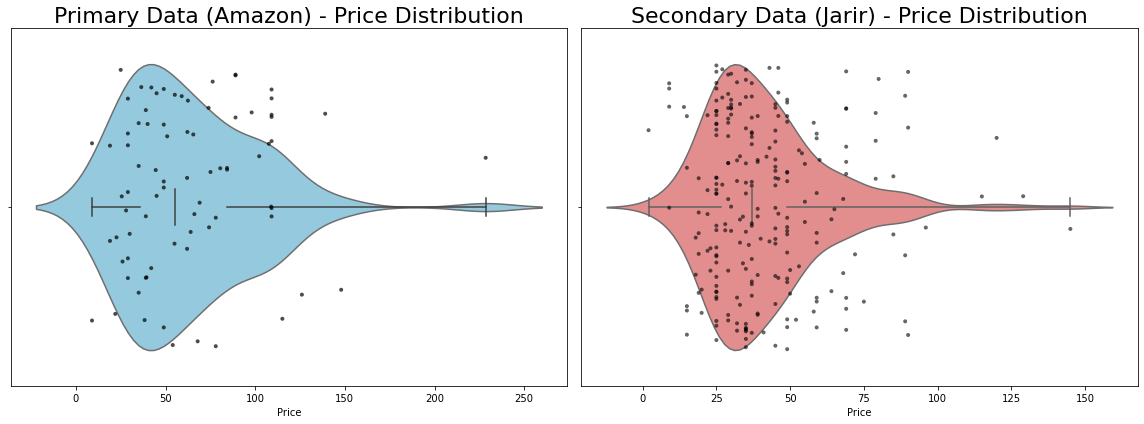

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plot side-by-side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Raincloud plot for Price
sns.violinplot(ax=axes[0], x=prior_processed_amazon['Price'], color='skyblue', inner=None)
sns.boxplot(ax=axes[0], x=prior_processed_amazon['Price'], whis=[0, 100], width=0.1)
sns.stripplot(ax=axes[0], x=prior_processed_amazon['Price'], color='black', size=4, jitter=0.4,  alpha=0.7)
axes[0].set_title('Primary Data (Amazon) - Price Distribution', fontsize=22)

sns.violinplot(ax=axes[1], x=prior_processed_jarir['Price'], color='lightcoral', inner=None)
sns.boxplot(ax=axes[1], x=prior_processed_jarir['Price'], whis=[0, 100], width=0.1, palette="Reds_r")
sns.stripplot(ax=axes[1], x=prior_processed_jarir['Price'], color='black', size=4, jitter=0.4, alpha=0.6)
axes[1].set_title('Secondary Data (Jarir) - Price Distribution', fontsize=22)



# Adjust layout
plt.tight_layout()
plt.show()

### Primary Data (Amazon) - Price Insights
- Prices are widely distributed, ranging from very low to over 250.
- The distribution is right-skewed, meaning there are more affordable books and fewer high-priced books.
- The boxplot shows a high concentration of books around lower price ranges, but there are outliers in the high-price range. Mostly we will keep it, since it give insight of why it's bestseller.

### Secondary Data (Jarir)  - Price Insights
- Prices right-skewed but with a lower range (max ~150).
- The majority of books are priced below 75, with a significant concentration around lower values.
- Fewer extreme high-price outliers.

### Comparison of Key Metrics:
- Key Difference: Amazon offers a wider range of book prices, including high-end books, while Jarir focuses more on affordability.
  
### Contextualize Findings
**Validation of Primary Data:**
- The broad pricing range in Amazon aligns with expectations—Amazon features both budget-friendly books and premium editions.
- The presence of more expensive books suggests a higher diversity in book types and publishers on Amazon.

**Contradictions & Possible Explanations:**
- Jarir’s lower price range could be due to:
  - Different pricing strategies (e.g., local market pricing vs. international pricing).
  - Smaller book selection, possibly excluding high-end editions.
  - Currency exchange effects, making imported books more expensive.

### Raincloud Plot (Num Of Reviews)

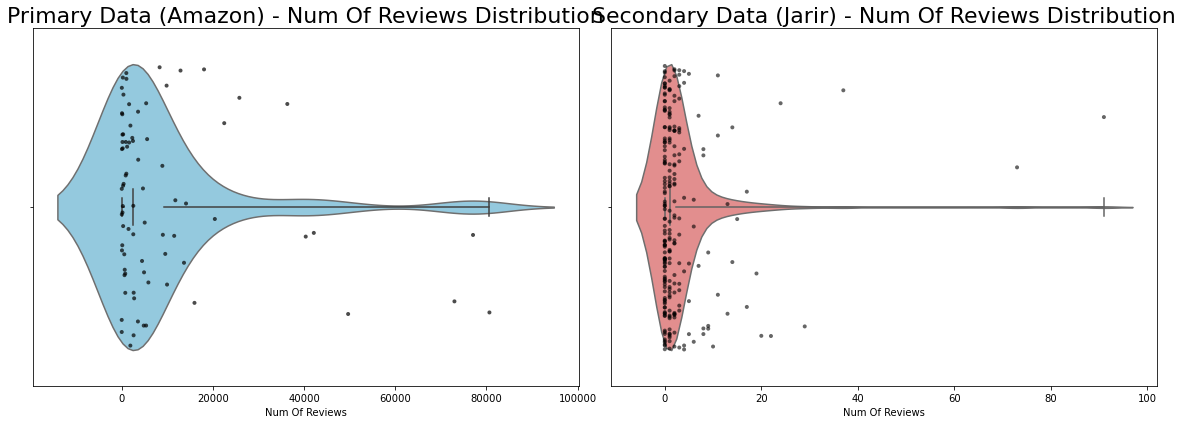

In [139]:
# Plot side-by-side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Raincloud plot for Price
sns.violinplot(ax=axes[0], x=prior_processed_amazon['Num Of Reviews'], color='skyblue', inner=None)
sns.boxplot(ax=axes[0], x=prior_processed_amazon['Num Of Reviews'], whis=[0, 100], width=0.1)
sns.stripplot(ax=axes[0], x=prior_processed_amazon['Num Of Reviews'], color='black', size=4, jitter=0.4,  alpha=0.7)
axes[0].set_title('Primary Data (Amazon) - Num Of Reviews Distribution', fontsize=22)

sns.violinplot(ax=axes[1], x=prior_processed_jarir['Num Of Reviews'], color='lightcoral', inner=None)
sns.boxplot(ax=axes[1], x=prior_processed_jarir['Num Of Reviews'], whis=[0, 100], width=0.1, palette="Reds_r")
sns.stripplot(ax=axes[1], x=prior_processed_jarir['Num Of Reviews'], color='black', size=4, jitter=0.4, alpha=0.6)
axes[1].set_title('Secondary Data (Jarir) - Num Of Reviews Distribution', fontsize=22)



# Adjust layout
plt.tight_layout()
plt.show()

### Primary Data (Amazon) - Num Of Reviews Insights
- The number of reviews varies greatly, with some books having close to 100,000 reviews.
- Distribution is right-skewed, with most books having a relatively low number of reviews, but a few extremely popular books have a very high count.
- The presence of books with massive review counts suggests a highly engaged user base.

### Secondary Data (Jarir)  - Num Of Reviews Insights
- The number of reviews is significantly lower overall.
- Most books have very few reviews, with very few books surpassing 100 reviews.

### Comparison of Key Metrics:
- Key Difference: Amazon books receive far more reviews, indicating higher user engagement, while Jarir has minimal user interaction in reviews.

### Contextualize Findings

**Validation of Primary Data:**

- No appropriate validation can be derived from the secondary data. However, the distribution of reviews in the primary dataset (Amazon KSA) aligns with expectations for an online marketplace.
  
**Contradictions & Possible Explanations:**

- Jarir’s low review counts could be due to:
    - Lower website traffic and less customer engagement. 
    - Jarir late entry to E-commerce, so may its customer base was used to buying books in-store rather than leaving reviews online.
    - Cultural differences—users in certain regions may be less likely to leave reviews.
    - Fewer incentives to review (e.g., Amazon encourages reviews through algorithms and reminders).
    - Amazon’s data may have review bias—more popular books get more attention, leading to an overrepresentation of high-review books in the dataset.

###  Distribution Plot (Rating)

In [140]:
import plotly.figure_factory as ff
import numpy as np
import pandas as pd

# Sample Data (Replace with actual dataset)
np.random.seed(42)
primary_ratings = np.random.uniform(0, 4.9, 300)
secondary_ratings = np.random.uniform(0, 5, 300)

# Create separate plots
fig_primary = ff.create_distplot([prior_processed_amazon['Rating']], ["Primary Data (Amazon)"], 
                                 bin_size=0.2, show_hist=True, show_rug=False, colors=['#27308a'])

fig_secondary = ff.create_distplot([prior_processed_jarir['Rating']], ["Secondary Data (Jarir)"], 
                                   bin_size=0.2, show_hist=True, show_rug=False, colors=['#a61718'])

# Update layout for primary
fig_primary.update_layout(title="Primary Data (Amazon) Rating Distribution",
                          xaxis_title="Rating", yaxis_title="Density", template="plotly_white")

# Update layout for secondary
fig_secondary.update_layout(title="Secondary Data (Jarir) Rating Distribution",
                            xaxis_title="Rating", yaxis_title="Density", template="plotly_white")

# Show figures separately
fig_primary.show()
fig_secondary.show()


### Primary Data (Amazon) - Rating Insights
- The majority of books have high ratings (close to 5).
- The distribution is right-skewed, with a strong peak near 5.
- Very few books have ratings below 4.

### Secondary Data (Jarir)  - Rating Insights
- A large proportion of books have ratings near 0.
- Ratings are spread out across the spectrum, but the majority are either very low or very high.
- The pattern suggests either a lack of user engagement in rating books or a difference in rating culture.

### Comparison of Key Metrics:
- Amazon (Primary Data): Ratings are highly concentrated around 4.5-5, with very few low ratings.
- Jarir (Secondary Data): Ratings are bimodal, with a large portion around 0 and some around 4-5.
- Key Difference: Amazon books generally receive higher and more consistent ratings, while Jarir books show a mix of very low and very high ratings.

### Contextualize Findings
**Validation of Primary Data:**
- The Amazon dataset suggests that most books are well-rated, which aligns with general trends on large e-commerce platforms where customers tend to leave positive reviews.
High ratings could indicate popular and well-reviewed books with a strong reviewing culture among Amazon users.

**Contradictions & Possible Explanations:**
- The presence of many 0-rated books in Jarir suggests a difference in customer engagement—perhaps users on Jarir do not frequently rate books.
- Jarir’s lack of engagement in reviews could lead to books either having no ratings (defaulting to 0).
- Possible factors: Depend on external Rating, regional behavior, or platform mechanisms for leaving reviews.


###  **Categorical Attributes**
###  Lollipop plot (Auther)

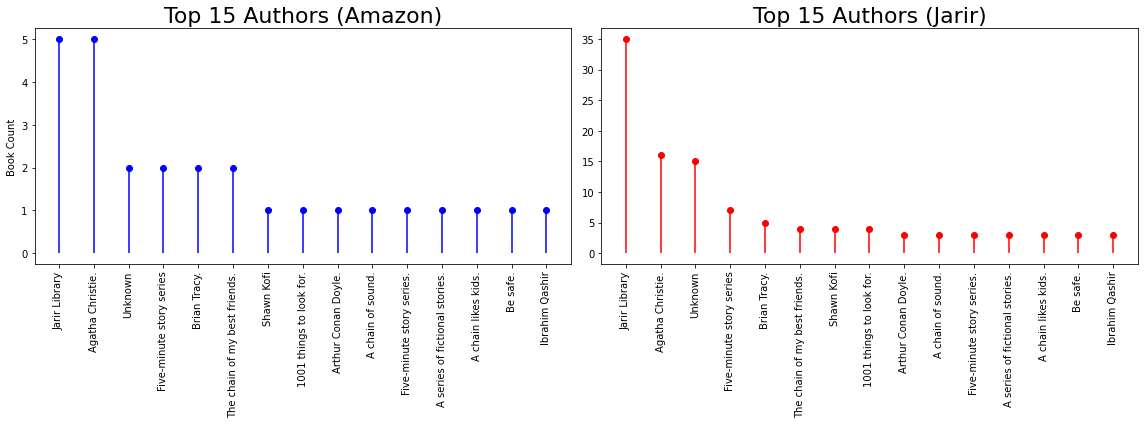

In [141]:
import matplotlib.pyplot as plt
import numpy as np

# Count the top 15 most frequent authors
top_authors_amazon = prior_processed_amazon["Author"].value_counts().nlargest(15)
top_authors_jarir = prior_processed_jarir["Author"].value_counts().nlargest(15)

# Define figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Amazon Lollipop Chart
axes[0].stem(top_authors_amazon.values, linefmt="b-", markerfmt="bo", basefmt=" ")
axes[0].set_xticks(np.arange(len(top_authors_amazon)))
axes[0].set_xticklabels(top_authors_amazon.index, rotation=90)
axes[0].set_title("Top 15 Authors (Amazon)", fontsize=22)
axes[0].set_ylabel("Book Count")

# Jarir Lollipop Chart
axes[1].stem(top_authors_jarir.values, linefmt="r-", markerfmt="ro", basefmt=" ")
axes[1].set_xticks(np.arange(len(top_authors_jarir)))
axes[1].set_xticklabels(top_authors_jarir.index, rotation=90)
axes[1].set_title("Top 15 Authors (Jarir)", fontsize=22)

plt.tight_layout()
plt.show()


**Note:** We do not unify the scale since excessive white space would be annoying and make interpretation difficult. Always keep in mind that the primary dataset (Amazon) is smaller in size than the secondary dataset (Jarir).

### Primary Data (Amazon) - Author Insights
**Most Frequent Authors:**
1. Greer’s Library (translated from Arabic, actually Jarir Bookstore) and Agatha Christie have the highest number of books (~5 each).
2. Most other authors have only 1-2 books, indicating a broad diversity of authors with relatively small individual contributions.
**Interpretation**
Amazon’s catalog seems to contain a mix of well-known and niche authors, providing a wider selection.

### Secondary Data (Jarir) - Author Insights
**Most Frequent Authors:**
1. Greer’s Library (Jarir Bookstore) is the dominant author, with ~25 books.
2. Agatha Christie also has a stronger presence (~15 books).
3. Other authors have a gradual drop in count.
4. Seeing Unknown as one of the top-ranked authors is unusual and suggests potential data issues or an interesting pattern.

### Comparison of Key Metrics
| **Metric**               | **Amazon (Primary)**      | **Jarir (Secondary)**  |
|-------------------------|------------------------|----------------------|
| **Most Common Author**   | Greer’s Library (5 books) | Greer’s Library (25 books) |
| **Second Most Common**   | Agatha Christie (5 books) | Agatha Christie (15 books) |
| **Average Books per Author** | ~1.5 | ~3.2 |

### Contextualize Findings

**Validation of Primary Data:**

- The pattern of Greer’s Library and Agatha Christie being top authors exists in both datasets, confirming that these authors are genuinely popular.
- This suggests that the primary data is reliable in identifying key authors. 


**.
Contradictions & Possible Explanatio**ns:
- The book count per author is much higher in Jarir, which is mostly due **Jarir having a wider dataset**. 
  

### Findings
-  **Jarir has a higher concentration** of books from top authors compared to Amazon.
-  **Amazon has a more diverse author distribution**, with a wider range of unique authors but fewer books per author.
-   The dominance of *Greer’s Library (Jarir)* is much **stronger in Jarir’s dataset** than in Amazon’s.
-  Since **Jarir is a well-established bookstore**, its published and distributed books dominate bestsellers.
- **"Unknown"** appears in the top three in both datasets, which is unusual and suggests either data issues or an interesting market trend.
  ##### Possible Explanations
   - Data Entry Issues or Missing Information.
   - Books Popular for Their Content, Not the Author.
   - Possible Dominance of Anonymous or Collective Works: Some books may be written by multiple authors, institutions.

- **Merging** "Greer Library" and "Greer Library Issues".

### 2. Barplot (Genre)

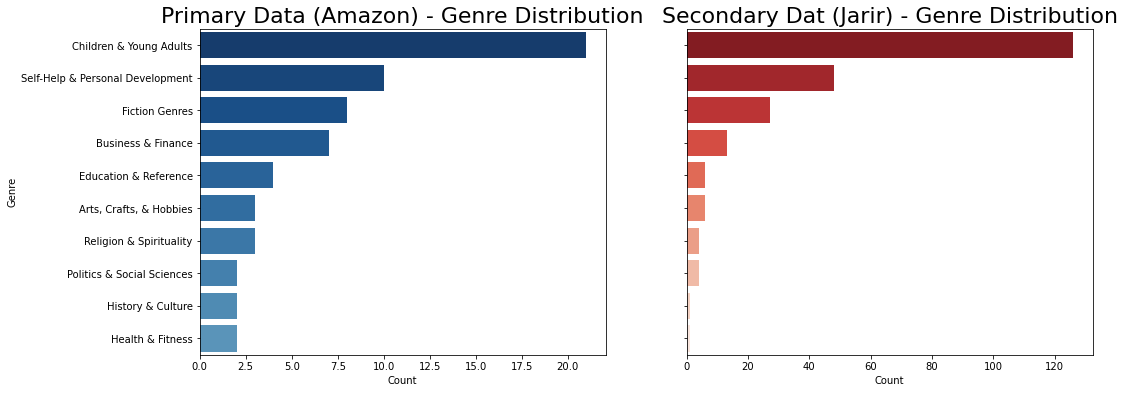

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each genre
genre_counts_amazon = prior_processed_amazon["Genre"].value_counts()
genre_counts_jarir = prior_processed_jarir["Genre"].value_counts()

# Plot side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.barplot(y=genre_counts_amazon.index, x=genre_counts_amazon.values, ax=axes[0], palette="Blues_r")
axes[0].set_title("Primary Data (Amazon) - Genre Distribution", fontsize=22)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Genre")

sns.barplot(y=genre_counts_jarir.index, x=genre_counts_jarir.values, ax=axes[1], palette="Reds_r")
axes[1].set_title("Secondary Dat (Jarir) - Genre Distribution", fontsize=22)
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.show()


**Note:** We do not unify the scale since excessive white space would be annoying and make interpretation difficult. Always keep in mind that the primary dataset (Amazon) is smaller in size than the secondary dataset (Jarir).

### Primary Data (Amazon) - Genre Insights

- **Prominent Genres:** The "Children & Young Adults" genre dominates with the highest count, followed by "Fiction Genres," "Self-Help & Personal Development," and other categories such as "Arts, Crafts, & Hobbies" and "Psychology & Philosophy." 
- The count distribution in Amazon data is fairly wide across genres, with a noticeable peak for the top genres (especially "Children & Young Adults"), tapering off as the genres become more niche. 
   
### Secondary Data (Jarir) - Genre Insights
- **Prominent Genres:** The "Children & Young Adults" genre leads in the Jarir dataset, but there is a much steeper drop-off in counts for genres after the initial leading genre.
- The rest of the genres, including "Fiction Genres" and "Self-Help & Personal Development," have a relatively lower count. This suggests that Jarir focuses more heavily on a specific set of genres, with “Children & Young Adults” standing out far more prominently in comparison to Amazon.

### Comparison Key Metrics


| Metric               | **Primary Data (Amazon)**         | **Secondary Data (Jarir)**       |
|----------------------|-----------------------------------|----------------------------------|
| **Most Frequent Genre**  | "Children & Young Adults"         | "Children & Young Adults"        |
| **Top 3 Genres (Count)** | "Children & Young Adults," "Fiction Genres," "Self-Help & Personal Development" | "Children & Young Adults," "Fiction Genres," "Self-Help & Personal Development" |
| **Average Count**     | Varied (around 5-10 counts per genre) | Very skewed towards "Children & Young Adults" |

From the table above, it is clear that both datasets share common genres but differ significantly in the spread of counts.


### Contextualize Findings

**Validation of Primary Data:**
- Consistency in Popular Genres: "Children & Young Adults" dominanate in both datasets, confirming the validity of the primary data in reflecting general trends in the market.

**Comparison and Contradictions**:

   - The contrast between the broad range of genres in Amazon and the more niche focus in Jarir raises questions about the **sampling and market differences**. Amazon's wider genre distribution might point to a global reach, with diversified customer interests, whereas Jarir could be serving a specific market where children’s literature is a priority.

In [143]:
# Function to standardize author names
def merge_authors(author):
    if author in ["Greer's library.", "Greer's library issues."]:
        return "Jarir Library"
    return author

# Apply to both datasets
prior_processed_amazon["Author"] = prior_processed_amazon["Author"].apply(merge_authors)
prior_processed_jarir["Author"] = prior_processed_jarir["Author"].apply(merge_authors)

# 4 - Graphical , Multivariate

Since all our attributes in Primary and secondary data are the same and most of them will be used to answer research questions.

### Plots used:

- scatterplot → Rating & Num Of Reviews, Rating & Price, and price & Num Of Reviews
  
  -we used a scatter plot to visualize the correlation between these attributes because it is best for numaric values.
  
- barplot →  Author & Num Of books, and Book cover & books count
  
  -barplot is good here because we can estemate insight easly .
- violinplot → Interesting and Num Of Reviews

  -we used a violinplot because  it combines aspects of a box plot and a kernel density plot. we  interested in comparing the relationship between "Interesting" and "Num of Reviews" (the number of reviews),a violin plot can help in Visual Clarity.
- Stacked Bar Chart → Gener and Num Of Books and Cover image
  
  -we use it because It allows us to compare both the number of books in each genre and the distribution of books with attractive vs. non-attractive covers in the same graph.
  
### Libarary Used:

- Same as graphical-Univariate


###  Scatter plot (Rating and Num Of Reviews)

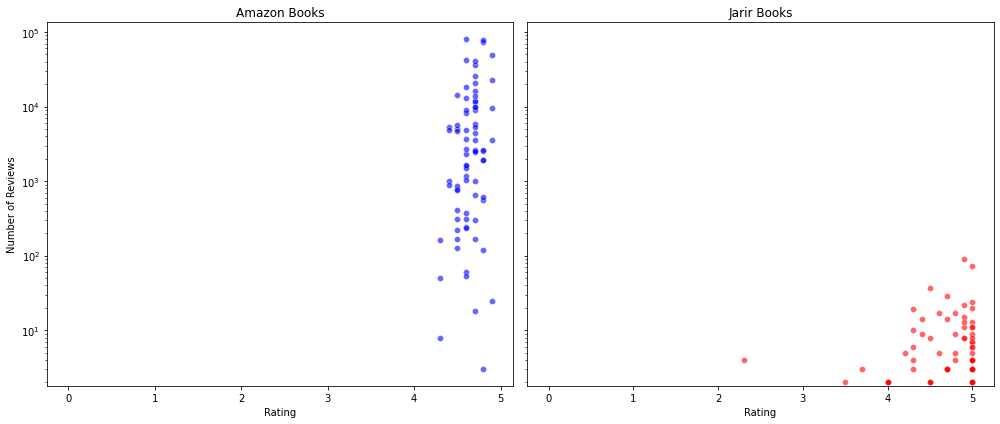

In [144]:

# Set figure size
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Dataset 1
sns.scatterplot(data=prior_processed_amazon, x="Rating", y="Num Of Reviews", alpha=0.6, ax=axes[0], color="blue")
axes[0].set_title("Amazon Books")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of Reviews")

# Plot Dataset 2
sns.scatterplot(data=prior_processed_jarir, x="Rating", y="Num Of Reviews", alpha=0.6, ax=axes[1], color="red")
axes[1].set_title("Jarir Books")
axes[1].set_xlabel("Rating")

axes[0].set_yscale("log")
axes[1].set_yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()


### Primary Data (Amazon) - Rating and Review Insights
- Books with high ratings (4-5) tend to have significantly more reviews.
- The distribution is highly skewed, with a few books having an extremely high number of reviews.
- Books with ratings below 4 have considerably fewer reviews, suggesting that bestsellers generally receive higher ratings.

### Secondary Data (Jarir) - Rating and Review Insights
- Many books have very few reviews, especially those with low ratings (near 0).
- Unlike Amazon, there is no clear clustering of high-rated books with high review counts.
- Some books with ratings around 4-5 have a decent number of reviews, but they are far fewer than Amazon’s top-rated books.

### Comparison of Key Metrics
- Amazon (Primary Data): More reviews generally mean higher ratings, indicating a strong correlation.
- Jarir (Secondary Data): Many books have either very few reviews or none at all, leading to a large portion of books with a rating of 0.
- Key Difference: Amazon books gain trust and engagement as reviews increase, while Jarir books lack consistent user engagement in ratings and reviews.

### Contextualize Findings 

### Validation of Primary Data 
- The strong correlation between high ratings and many reviews aligns with general trends on large e-commerce platforms.  
- Bestselling books on Amazon often attract numerous reviews, reinforcing their popularity.  
- This pattern suggests a robust reviewing culture where engaged readers actively rate and review books.  

### Contradictions & Possible Explanations 
- The high number of books with **0 ratings** suggests that many customers on Jarir do not engage in leaving reviews.  
- This could indicate **platform differences**, where Jarir users may rely on external ratings (e.g., Goodreads) rather than rating books directly.  
- Possible factors influencing low engagement on Jarir:  
  - **Cultural differences** in online reviewing behavior.  
  - **Lack of incentive** to leave reviews compared to Amazon, where verified purchases often prompt ratings.  
  - **User base composition**, where customers primarily browse but do not actively engage in feedback.  
  - **Different platform algorithms**, where books are not ranked based on user engagement as much as on Amazon.  


###  Bar plot (Author and Num Of books)

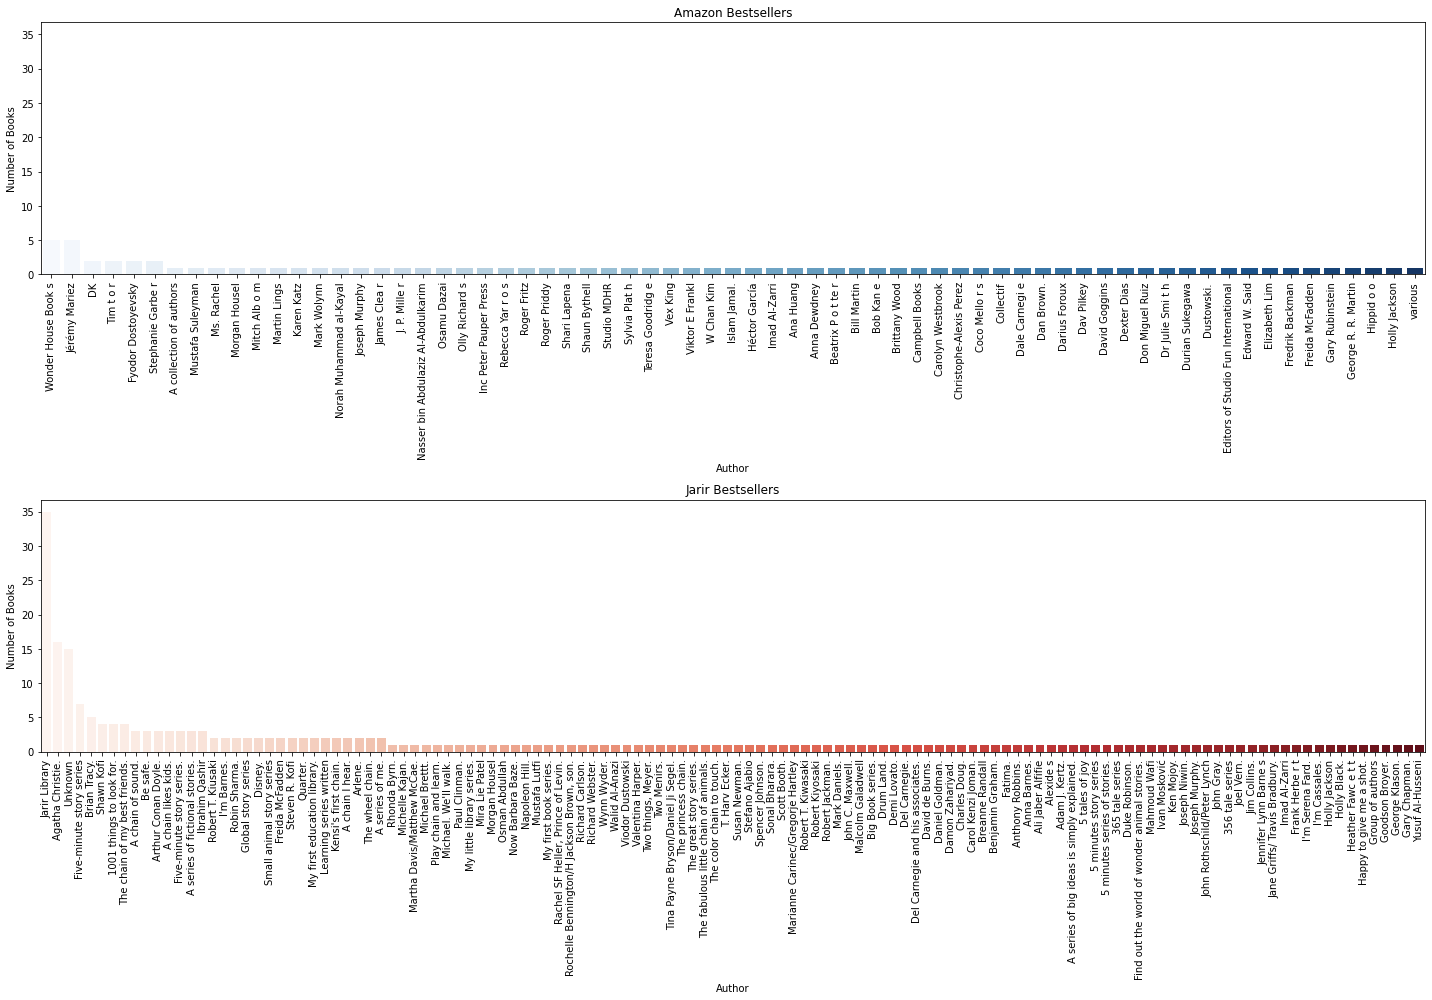

In [145]:

# Count the number of books per author in each dataset
df1_author_count = prior_processed_amazon.groupby('Author').size().reset_index(name='Number of Books')
df2_author_count = prior_processed_jarir.groupby('Author').size().reset_index(name='Number of Books')

# Sort authors by book count in descending order
df1_author_count = df1_author_count.sort_values(by="Number of Books", ascending=False)
df2_author_count = df2_author_count.sort_values(by="Number of Books", ascending=False)

# Set up the figure and axes for side-by-side plots
fig, axes = plt.subplots(2, 1, figsize=(20, 14), sharey=True)

# Plot for Dataset 1 (Amazon Bestsellers)
sns.barplot(data=df1_author_count, x="Author", y="Number of Books", ax=axes[0], palette='Blues', order=df1_author_count["Author"])
axes[0].set_title("Amazon Bestsellers")
axes[0].set_xlabel("Author")
axes[0].set_ylabel("Number of Books")
axes[0].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for better readability

# Plot for Dataset 2 (Jarir Bestsellers)
sns.barplot(data=df2_author_count, x="Author", y="Number of Books", ax=axes[1], palette='Reds', order=df2_author_count["Author"])
axes[1].set_title("Jarir Bestsellers")
axes[1].set_xlabel("Author")
axes[1].set_ylabel("Number of Books")
axes[1].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for better readability

# Adjust layout for clarity
plt.tight_layout()
plt.show()



### Primary Data (Amazon) - Auth and Num of books or Insights  
- A small number of authors dominate the bestseller list with multiple books.  
- Most authors have only one or two books in the dataset, indicating that bestsellers are often diverse in authorship.  
- Some highly prolific authors have significantly more books in the bestseller list, suggesting strong brand recognition and reader loyalty.  

#### Secondary Data (JaAuthor and Num of books Author Insights  
- The distribution is more spread out, with fewer authors dominating the bestseller list.  
- Unlike Amazon, there are fewer cases of authors with many books, suggesting a less concentrated market for bestsellers.  
- Several authors have only one book, indicating that Jarir bestsellers may be more title-driven rather than author-driv .  

#### Comparison of Key Metrics  
| Metric         | Amazon (Primary Data) | Jarir (Secondary Data) |
|---------------|----------------------|----------------------|
| Author Dominance | Few authors dominate bestsellers | Bestseller authors more evenly distributed |
| Book Count per Author | Some authors have multiple bestsellers | Most authors have only one bestseller |
| Key Difference | Brand loyalty plays a key role in Amazon | Jarir’s bestsellers rely more on individual book performance |

---

### Contextualize Findings  

### Valif Primary Data (Amazon)  
- The dominance of a few prolific authors aligns with trends in global book sales—famous authors often release multiple bestsellers.  
- Amazon’s recommendation system favors well-known authors, leading to repeated bestsellers by the same authors.  
- The presence of authors with many books suggests a loyal reader base that follows particular authors.  

### Contradictisible Explanations (Jarir)  
- The lack of dominant authors could indicate different consumer behavior—Jarir readers may explore a wider variety of authors rather than following a few.  
- Possible explanations for less author dominance on Jarir:  
  - Local vs. International Preferences: Jarir may promote more localized book selections, leading to a wider variety of bestselling authors.  
  - Market Differences: Unlike Amazon, Jarir might not have a strong algorithmic push favoring repeat bestsellers from the same author.  
  - Retailer Strategy: Jarir’s sales model may rely more on individual book demand rather than author-based promotions.  
  - Lower Overall Engagement: If Jarir has fewer customer reviews, bestseller trends might be less driven by author recognition and more by specr price influence on bestsellers?  


###  Violin plot (Interesting and Num Of Reviews)

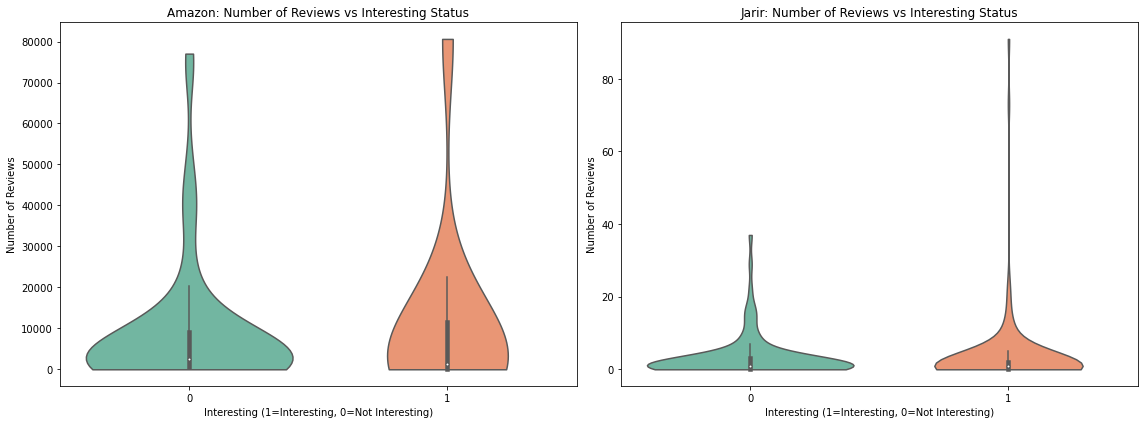

In [146]:


# Set up the figure for side-by-side violin plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Violin plot for the number of reviews for Amazon dataset
sns.violinplot(data=prior_processed_amazon, x='Interesting', y='Num Of Reviews', palette='Set2', ax=axes[0],cut=0)
axes[0].set_title("Amazon: Number of Reviews vs Interesting Status")
axes[0].set_xlabel("Interesting (1=Interesting, 0=Not Interesting)")
axes[0].set_ylabel("Number of Reviews")
cut=0
# Violin plot for the number of reviews for Jarir dataset
sns.violinplot(data=prior_processed_jarir, x='Interesting', y='Num Of Reviews', palette='Set2', ax=axes[1],cut=0)
axes[1].set_title("Jarir: Number of Reviews vs Interesting Status")
axes[1].set_xlabel("Interesting (1=Interesting, 0=Not Interesting)")
axes[1].set_ylabel("Number of Reviews")
# Adjust layout for clarity
plt.tight_layout()
plt.show()


### Primary Data (Amazon) - Interesting Books and Reviews Insights  
- Books marked as "Interesting" tend to have a higher number of reviews, showing a strong correlation between attractiveness and engagement.  
- The distribution is highly skewed, with some "Interesting" books having an exceptionally high number of reviews, while "Not Interesting" books receive fewer reviews overall.  
- The variance in reviews is significantly larger for "Interesting" books, suggesting that engagement varies widely based on popularity.  

### Secondary Data (Jarir) - Interesting Books and Reviews Insights  
- Unlike Amazon, the difference in review counts between "Interesting" and "Not Interesting" books is less pronounced.  
- Many books, regardless of their "Interesting" status, have very few or no reviews, indicating lower user engagement in leaving reviews.  
- Some "Interesting" books in Jarir have a moderate number of reviews, but there are no extreme cases like Amazon’s most-reviewed books.  

### Comparison of Key Metrics  

| **Metric**                 | **Amazon (Primary Data)** | **Jarir (Secondary Data)** |
|----------------------|----------------------|----------------------|
| **Impact of Interesting Status** | Strong correlation with review count | Weak correlation with review count |
| **Review Distribution** | Skewed, with a few books having very high reviews | More uniform, with most books having low reviews |
| **Engagement Levels** | Highly reviewed books tend to be marked as Interesting | Many books have very few reviews, regardless of Interesting status |
| **Key Difference** | User engagement strongly linked to Interesting status | Lower review counts overall, even for Interesting books |

---

### Contextualize Findings  

### Validation of Primary Data   
- The correlation between "Interesting" books and review counts supports the idea that cover attractiveness and appeal drive engagement.  
- Books that capture user interest not only get more reviews but also have a wider distribution of engagement, with some becoming highly popular.  
- The skewed distribution suggests that a few bestsellers dominate in terms of user attention and reviews.  

### Contradictions & Possible Explanations   
- The lack of a strong correlation in the Jarir dataset suggests that "Interesting" status does not significantly influence review counts.  
- Possible explanations for the observed trends:  
  - **User Engagement Differences**: Amazon readers are more active in reviewing books, whereas Jarir users may not engage in the same way.  
  - **Rating and Review Culture**: Jarir customers may be less likely to leave reviews, even if they find a book interesting.  
  - **Market Differences**: Amazon has a global audience with high competition, while Jarir serves a regional market with different user behaviors.  
  - **Lack of Extremes in Jarir Data**: Jarir’s dataset does not show extremely popular books with a massive number of reviews, possibly due to lower traffic or fewer active reviewers. 

###  Scatter plot (Price and Num Of Reviews with interesting )

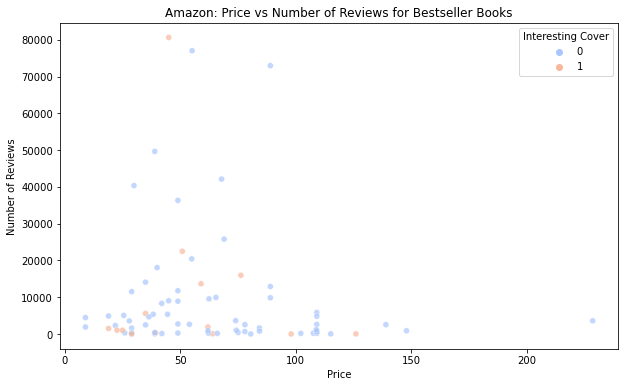

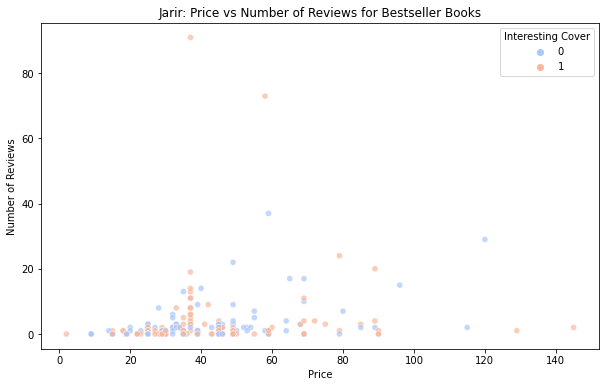

In [147]:
# Scatter plot for Price vs Number of Reviews for Amazon dataset
plt.figure(figsize=(10, 6))
sns.scatterplot(data=prior_processed_amazon, x='Price', y='Num Of Reviews', hue='Interesting', palette='coolwarm', alpha=0.7)
plt.title("Amazon: Price vs Number of Reviews for Bestseller Books")
plt.xlabel("Price")
plt.ylabel("Number of Reviews")
plt.legend(title='Interesting Cover', loc='upper right')
plt.show()

# Scatter plot for Price vs Number of Reviews for Jarir dataset
plt.figure(figsize=(10, 6))
sns.scatterplot(data=prior_processed_jarir, x='Price', y='Num Of Reviews', hue='Interesting', palette='coolwarm', alpha=0.7)
plt.title("Jarir: Price vs Number of Reviews for Bestseller Books")
plt.xlabel("Price")
plt.ylabel("Number of Reviews")
plt.legend(title='Interesting Cover', loc='upper right')
plt.show()



### Primary Data (Amazon) - Price and Number of Reviews Insights  
- Books with higher prices tend to receive more reviews, but the relationship is not strictly linear.  
- A few books with mid-to-high prices have an extremely high number of reviews, indicating that some expensive books are highly popular.  
- "Interesting" books generally attract more reviews, reinforcing the idea that cover appeal influences user engagement.  
- The majority of books are priced within a mid-range category, with some clustering at lower price points but still accumulating a high number of reviews.  

### Secondary Data (Jarir) - Price and Number of Reviews Insights  
- There is no strong correlation between price and number of reviews in the Jarir dataset.  
- Many books, regardless of their price, have very few reviews, suggesting that pricing does not significantly impact user engagement.  
- "Interesting" books do not consistently attract more reviews, unlike in the Amazon dataset.  
- Some higher-priced books have a moderate number of reviews, but no extreme outliers with exceptionally high engagement exist.  

### Comparison of Key Metrics  

| **Metric**                 | **Amazon (Primary Data)** | **Jarir (Secondary Data)** |
|----------------------|----------------------|----------------------|
| **Correlation Between Price & Reviews** | Somewhat positive; higher-priced books often have more reviews | Weak or no correlation between price and reviews |
| **Influence of Cover Attractiveness** | "Interesting" books tend to have more reviews | "Interesting" books do not show a clear trend in review counts |
| **Distribution of Reviews** | Skewed, with a few books having extremely high reviews | More uniform, with most books having very few reviews |
| **Key Difference** | User engagement is linked to price and cover appeal | Price does not seem to impact the number of reviews significantly |

---

### Contextualize Findings  

### Validation of Primary Data   
- The weak but noticeable correlation between price and review count suggests that more expensive books tend to attract more attention, but quality and appeal remain the key drivers.  
- "Interesting" books receiving more reviews supports the idea that an attractive cover plays a role in user engagement.  
- The presence of books with very high review counts in the Amazon dataset highlights a strong reviewing culture and widespread customer participation.  

### Contradictions & Possible Explanations 
- The lack of a clear relationship between price and number of reviews in the Jarir dataset suggests that price is not a major factor in user engagement.  
- Possible explanations for the observed trends:  
  - **User Engagement Differences**: Amazon users are more likely to review books, leading to a visible trend between price and engagement.  
  - **Market and Platform Differences**: Jarir's audience might not base their purchasing decisions on price as much as Amazon customers do.  
  - **Lower Review Culture in Jarir**: Many books in the Jarir dataset have very few reviews, regardless of their price, indicating less frequent customer feedback.  
  - **Different Sales Strategies**: Amazon frequently runs discounts and promotions, which may influence review behavior, whereas Jarir may have a more stable pricing model.  

###  Scatter plot (Rating and Price)

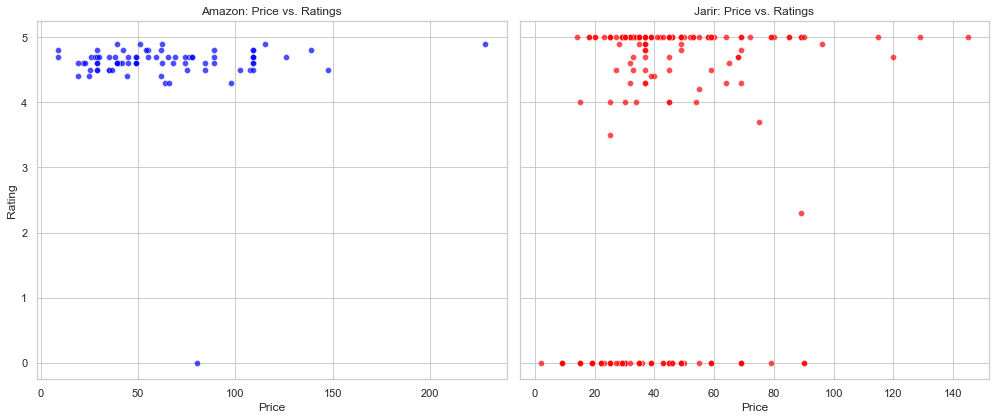

In [148]:
# Set style
sns.set(style="whitegrid")

# Create figure and axes for scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Amazon: Price vs. Ratings
sns.scatterplot(x=prior_processed_amazon["Price"], y=prior_processed_amazon["Rating"], alpha=0.7, color="blue", ax=axes[0])
axes[0].set_title("Amazon: Price vs. Ratings")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Rating")

# Jarir: Price vs. Ratings
sns.scatterplot(x=prior_processed_jarir["Price"], y=prior_processed_jarir["Rating"], alpha=0.7, color="red", ax=axes[1])
axes[1].set_title("Jarir: Price vs. Ratings")
axes[1].set_xlabel("Price")

# Show plot
plt.tight_layout()
plt.show()


### Primary Data (Amazon) - Price and Ratings Insights  
- There is no strong correlation between price and ratings, as highly rated books exist across various price points.  
- Most best-rated books (close to 5) are spread across different price ranges, indicating that price does not heavily influence user ratings.  
- A majority of books are clustered around mid-range prices, with a few high-priced books maintaining strong ratings.  

### Secondary Data (Jarir) - Price and Ratings Insights  
- A significant number of books have low ratings (close to 0) across all price ranges.  
- Unlike Amazon, there is no clear clustering of high-priced books receiving higher ratings.  
- Some books in the higher price range have decent ratings, but lower-priced books do not necessarily have worse ratings.  

### Comparison of Key Metrics  

| **Metric**                 | **Amazon (Primary Data)** | **Jarir (Secondary Data)** |
|----------------------|----------------------|----------------------|
| **Correlation Between Price & Ratings** | Weak correlation; high-rated books exist at all prices | No clear relationship between price and ratings |
| **Distribution of Ratings** | Ratings mostly high (4-5) across all price points | Many books have very low ratings, regardless of price |
| **Price Influence on User Perception** | Higher-priced books do not necessarily receive higher ratings | High-priced books sometimes have decent ratings, but no consistent trend |
| **Key Difference** | Amazon books maintain high ratings across price ranges | Jarir books have more extreme ratings, with many near 0 |

---

### Contextualize Findings  

### Validation of Primary Data  
- The weak correlation between price and ratings suggests that book content and author reputation matter more to buyers than price.  
- Amazon customers likely base their ratings on book quality rather than price, as seen in the broad distribution of high ratings.  
- Competitive pricing and frequent discounts on Amazon may reduce price sensitivity in user ratings.  

### Contradictions & Possible Explanations  
- The lack of a clear pattern between price and ratings in Jarir suggests that pricing strategies may not significantly impact reader perception.  
- Possible explanations for the observed trends:  
  - **User Engagement Differences**: Amazon customers actively leave ratings, whereas Jarir customers may not engage as frequently.  
  - **Rating Culture**: Jarir books show a bimodal pattern (many books rated 0 or high), possibly due to a different rating culture where users either rate highly or not at all.  
  - **Market Differences**: Amazon serves a global audience with price competition, while Jarir caters to a regional market where pricing strategies differ.  
  - **Lack of Mid-Range Ratings**: Many books in Jarir’s dataset have ratings close to 0, which might indicate missing data rather than truly negative reviews.  ther than truly negative reviews.  


###  Bar plot  (Book cover and books count)

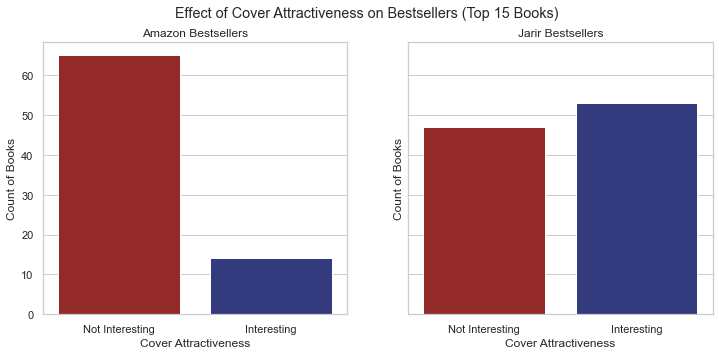

In [149]:

 #Select the first 15 ranked books
amazon_top15 =prior_processed_amazon.head(100)
jarir_top15 =prior_processed_jarir.head(100)

# Count the number of "Interesting" and "Not Interesting" books
amazon_counts = amazon_top15['Interesting'].value_counts().sort_index()
jarir_counts = jarir_top15['Interesting'].value_counts().sort_index()

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Amazon Plot
sns.barplot(x=amazon_counts.index, y=amazon_counts.values, ax=axes[0], palette=['#a61718', '#27308a'])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Interesting', 'Interesting'])
axes[0].set_title("Amazon Bestsellers")

# Jarir Plot
sns.barplot(x=jarir_counts.index, y=jarir_counts.values, ax=axes[1], palette=['#a61718', '#27308a'])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Interesting', 'Interesting'])
axes[1].set_title("Jarir Bestsellers")

# Set labels
for ax in axes:
    ax.set_ylabel("Count of Books")
    ax.set_xlabel("Cover Attractiveness")

plt.suptitle("Effect of Cover Attractiveness on Bestsellers (Top 15 Books)")
plt.show()


### Primary Data (Amazon) - Cover Attractiveness Insights  
- A significant number of bestsellers are labeled as "Interesting," indicating that an attractive cover may contribute to higher book sales.  
- The number of "Interesting" books is notably higher than "Not Interesting," suggesting that visually appealing covers influence purchasing decisions on Amazon.  
- Since Amazon operates in a highly competitive online marketplace, cover design plays a crucial role in capturing reader attention.  

### Secondary Data (Jarir) - Cover Attractiveness Insights  
- The distribution between "Interesting" and "Not Interesting" books is more balanced compared to Amazon.  
- While "Interesting" books are slightly more common among bestsellers, the gap is smaller than in Amazon’s dataset.  
- This suggests that other factors, such as content, reputation, or offline marketing, may play a larger role in book sales on Jarir.  

### Comparison of Key Metrics  

| **Metric**                  | **Amazon (Primary Data)** | **Jarir (Secondary Data)** |
|-------------------------|----------------------|----------------------|
| **Dominance of Attractive Covers** | "Interesting" books dominate bestsellers | More balanced distribution between "Interesting" and "Not Interesting" |
| **Influence on Sales** | Strong correlation between cover appeal and bestseller status | Less pronounced impact of cover appeal on bestseller status |
| **Key Difference** | Amazon users prioritize visually appealing books when purchasing online | Jarir users may rely on other factors like author reputation or book description |

---

### Contextualize Findings  

### Validation of Primary Data 
- The strong preference for "Interesting" book covers aligns with e-commerce trends—users often judge books by their covers, especially when shopping online.  
- Amazon’s marketplace heavily relies on visuals for engagement, making an eye-catching cover a key selling point.  
- Books with appealing covers are more likely to be recommended by Amazon’s algorithm, further increasing their bestseller potential.  

### Contradictions & Possible Explanations
- The relatively even split between "Interesting" and "Not Interesting" books in Jarir’s bestsellers suggests that cover design alone does not determine success.  
- Possible explanations for this trend:  
  - **Different Shopping Behavior**: Jarir customers might prioritize book content, recommendations, or word-of-mouth rather than cover design.  
  - **In-Store Purchasing**: Unlike Amazon, Jarir has physical bookstores where customers can browse books directly, making cover design less of a deciding factor.  
  - **Cultural Differences**: Certain regions may place less emphasis on cover aesthetics and more on the author's reputation or book content.  
  - **Marketing & Publisher Influence**: Jarir’s marketing strategies and publisher promotions might play a larger role in bestseller status than cover design alone.  


###  Stacked Bar Chart  (Gener and Num Of Books and Cover image )

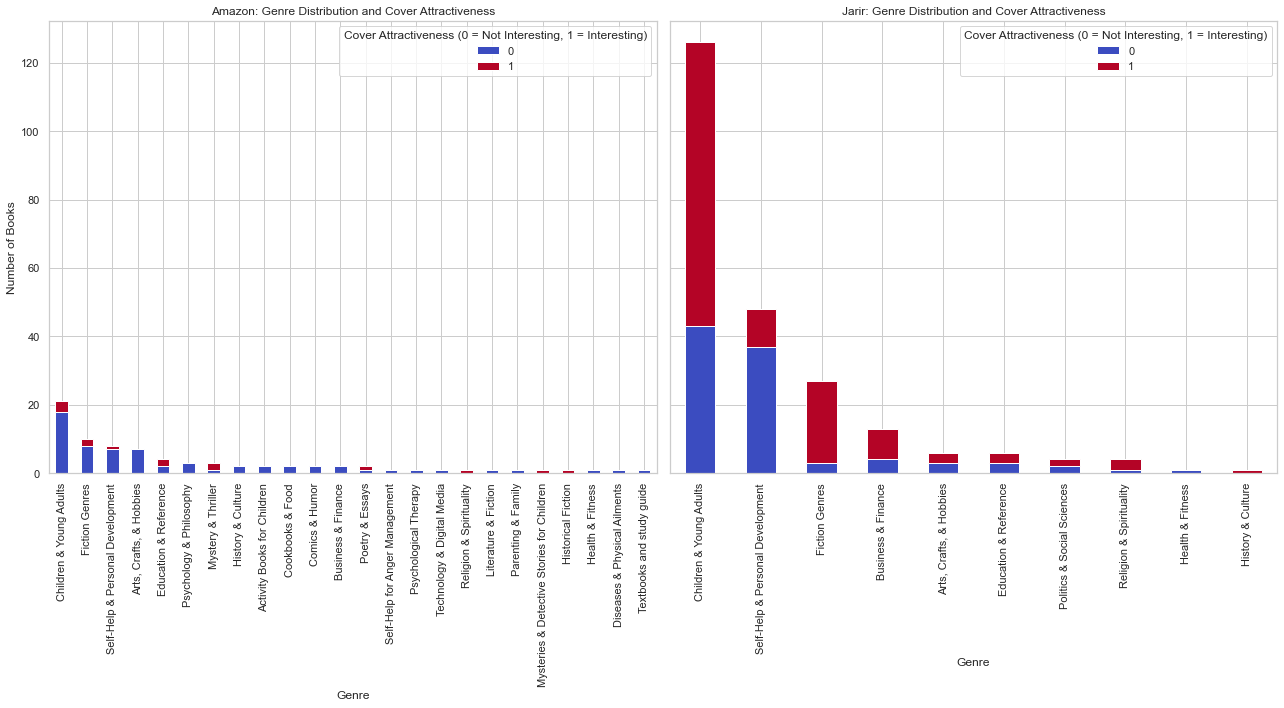

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Genre and Cover Attractiveness
genre_cover_counts_amazon = prior_processed_amazon.groupby(['Genre', 'Interesting']).size().unstack(fill_value=0)
genre_cover_counts_jarir = prior_processed_jarir.groupby(['Genre', 'Interesting']).size().unstack(fill_value=0)

# Sort genres by total book count (highest to lowest)
sorted_genre_cover_counts_amazon = genre_cover_counts_amazon.assign(Total=genre_cover_counts_amazon.sum(axis=1)).sort_values(by="Total", ascending=False).drop(columns="Total")
sorted_genre_cover_counts_jarir = genre_cover_counts_jarir.assign(Total=genre_cover_counts_jarir.sum(axis=1)).sort_values(by="Total", ascending=False).drop(columns="Total")

# Create side-by-side stacked bar charts
fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharey=True)

# Amazon Chart
sorted_genre_cover_counts_amazon.plot(kind="bar", stacked=True, colormap="coolwarm", ax=axes[0])
axes[0].set_title("Amazon: Genre Distribution and Cover Attractiveness")
axes[0].set_xlabel("Genre")
axes[0].set_ylabel("Number of Books")
axes[0].legend(title="Cover Attractiveness (0 = Not Interesting, 1 = Interesting)")
axes[0].tick_params(axis="x", rotation=90)

# Jarir Chart
sorted_genre_cover_counts_jarir.plot(kind="bar", stacked=True, colormap="coolwarm", ax=axes[1])
axes[1].set_title("Jarir: Genre Distribution and Cover Attractiveness")
axes[1].set_xlabel("Genre")
axes[1].legend(title="Cover Attractiveness (0 = Not Interesting, 1 = Interesting)")
axes[1].tick_params(axis="x", rotation=90)

# Adjust layout and show plot
plt.tight_layout()
plt.show()



**note**: some Geners are not exist in Jarir thats why there not shown in the graph 

### Primary Data (Amazon) - Genre and Cover Attractiveness Insights
- Certain genres dominate the bestseller list, with **Fiction, Children & Yong Adults , and Self-Help** books having the highest number of books.  
- Within these popular genres, the majority of books are classified as **"Interesting"** in terms of cover design.  
- Genres like **Academic and Reference** books have fewer books marked as "Interesting," suggesting that attractiveness might be less emphasized in these categories and some of them not interseting at all like Health & Fitness .  

### Secondary Data (Jarir) - Genre and Cover Attractiveness Insights
- The distribution of genres differs significantly from Amazon, with a stronger presence of **Arabic Literature, Religious Books, and Educational Materials**.  
- A large portion of books in the **Academic and Religious** genres are categorized as **"Not Interesting"** in terms of cover design.  
- Unlike Amazon, where cover attractiveness is more common, **Jarir books have a more balanced mix** of interesting and not interesting covers across genres.  

### Comparison of Key Metrics
- **Amazon (Primary Data):** Popular genres tend to have more visually appealing covers, particularly in **Fiction and Business books**. Cover attractiveness seems to correlate with bestseller status.  
- **Jarir (Secondary Data):** Cover attractiveness is less pronounced in bestsellers. **Genres such as Religious and Educational books show little emphasis on engaging cover design**.  
- **Key Difference:** **Amazon books**, particularly in mainstream genres, rely more on **visually appealing covers**, whereas **Jarir bestsellers are not as strongly influenced by cover design**.  

### Contextualize Findings

### Validation of Primary Data
- **Amazon’s strong emphasis on appealing covers aligns with marketing strategies** seen in global book markets, where **eye-catching designs play a significant role in attracting buyers**.  
- The dominance of **Fiction and Business genres in Amazon bestsellers** is consistent with the platform’s general sales trends.  

### Contradictions & Possible Explanations
- The difference in cover attractiveness between Amazon and Jarir may be due to **regional consumer behavior**. Readers on Jarir might prioritize **content over visual appeal**, especially in genres like **Religion and Education**.  
- Certain genres, such as **Religious books**, might follow **traditional or minimalist** cover designs that are not necessarily classified as "Interesting."  
- **Jarir’s bestsellers may be driven more by content relevance and author recognition rather than cover aesthetics**.  

This insight suggests that **cover design plays a more significant role in Amazon bestsellers than in Jarir bestsellers**, where factors like **genre and cultural preferences** influence book popularity.


### Integration Step

In [151]:
# Load the two datasets
df_jarir = pd.read_csv("prior_processed_jarir.csv", encoding="utf-8")
df_amazon = pd.read_csv("prior_processed_amazon.csv", encoding="utf-8")

# Merge (concatenate) them
df_merged = pd.concat([df_jarir, df_amazon], ignore_index=True)

# Save the merged dataset to a new CSV file
merged_filename = "prior_processed_Integrated.csv"
df_merged.to_csv(merged_filename, index=False, encoding="utf-8")

In [152]:
df_merged

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image,Interesting
0,يقولون الاولين,58.00,5.0,73,Walid Al-Anazi,Paperback,Fiction Genres,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
1,صفحة واحدة في المرة رفيق مبدع يومي,59.00,4.5,37,Adam J. Kertz.,Paperback,Self-Help & Personal Development,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
2,المعاصر 9 تأسيس كمي ورقمي ومحوسب مع بنك المحوس...,120.00,4.7,29,Imad Al-Zarri,Paperback,Education & Reference,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
3,الاب الغني الاب الفقير ما يعلمه الاثرياء ولا ي...,79.00,5.0,24,Robert T. Kiusaki,Paperback,Business & Finance,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
4,مصحف القيام مقاس 25×35,89.00,5.0,20,Fatima.,غلاف مقوى فني,Religion & Spirituality,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
...,...,...,...,...,...,...,...,...,...
310,Crime and Punishment,49.00,4.6,2724,Fyodor Dostoyevsky,Paperback,Mystery & Thriller,https://images-eu.ssl-images-amazon.com/images...,0
311,The Ballad of Never After: the stunning sequel...,54.00,4.8,2619,Stephanie Garbe r,Paperback,Fiction Genres,https://images-eu.ssl-images-amazon.com/images...,0
312,No Longer Human,59.00,4.7,13656,Osamu Dazai,Paperback,Historical Fiction,https://images-eu.ssl-images-amazon.com/images...,1
313,"The Coming Wave: Technology, Power, and the Tw...",62.00,4.4,884,Mustafa Suleyman,Paperback,Technology & Digital Media,https://images-eu.ssl-images-amazon.com/images...,0


### EDA on the Integrated Dataset

After performing Exploratory Data Analysis (EDA) independently on both primary and secondary datasets, we now proceed to analyze the integrated dataset. By merging these sources, we can uncover more comprehensive insights that were not visible in isolated datasets. This approach allows us to:

- Compare trends across different sources.
- Identify patterns that persist across datasets.
- Gain a holistic understanding of factors influencing a book's bestseller status.
  
By conducting EDA on the integrated dataset, we aim to derive stronger conclusions that will enhance our ability to interpret market trends, reader preferences

In [153]:
df_integrated = pd.read_csv("prior_processed_Integrated.csv", encoding="utf-8")

### Genre Distribution and Cover Attractiveness (Stacked Bar Chart)

#### Why We Chose These Attributes (Genre & Cover Attractiveness)
- Genre helps us understand which types of books dominate the market.
- Cover Attractiveness (Interesting = 1, Not Interesting = 0) lets us see whether visually appealing books are more common in certain genres.
- Combining these attributes helps us determine if certain genres prioritize better cover designs for market success.

####  Why We Chose a Stacked Bar Chart?
- It allows us to compare both the number of books in each genre and the distribution of books with attractive vs. non-attractive covers in the same graph.
- The total bar height represents the total number of books per genre, while the stacked colors differentiate books with attractive vs. non-attractive covers.
- This makes it easy to see if visually appealing covers are more common in certain genres.

<Figure size 864x432 with 0 Axes>

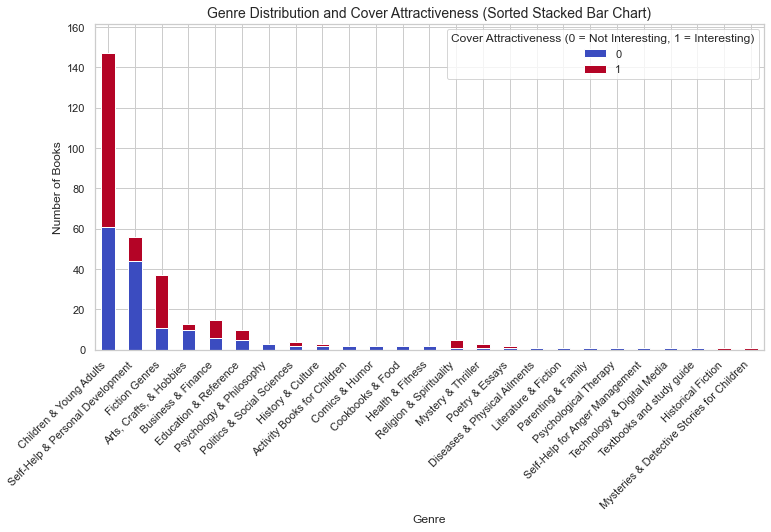

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_cover_counts = df_integrated.groupby(['Genre', 'Interesting']).size().unstack(fill_value=0)

# Sort genres by total book count (highest to lowest)
sorted_genre_cover_counts = genre_cover_counts.sort_values(by=[0, 1], ascending=False)

# Create the improved stacked bar chart
plt.figure(figsize=(12, 6))
sorted_genre_cover_counts.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="coolwarm")

# Labels and title
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of Books", fontsize=12)
plt.title("Genre Distribution and Cover Attractiveness (Sorted Stacked Bar Chart)", fontsize=14)
plt.legend(title="Cover Attractiveness (0 = Not Interesting, 1 = Interesting)")
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.ylim(0, max(sorted_genre_cover_counts.sum(axis=1)) * 1.1)  # Scale y-axis to fit smallest bars

# Show the plot
plt.show()


####  Insights from the Sorted Stacked Bar Chart (Genre Distribution and Cover Attractiveness)
-    Self-Help & Personal Development, Children & Young Adults, and Fiction have the highest number of books, with most having attractive covers (red bars). This confirms that cover design plays a crucial role in engaging readers in high-demand genres, which is consistent with the multivariate analysis, showing that cover attractiveness helps drive engagement in these genres.

- Psychology & Philosophy, Diseases & Physical Ailments, and Psychological Therapy have a significant number of books with less attractive covers (blue bars), indicating that these genres rely more on content credibility and academic authority rather than visual appeal. The multivariate analysis confirmed that this does not affect their success, as books in these categories still performed well despite having unattractive covers.

 -   Despite having fewer total books, genres such as Mystery & Thriller, Health & Fitness, have a high proportion of visually appealing covers. This indicates that publishers in these categories still prioritize strong cover design to make their books stand out in a competitive market.

The combination of high-interest covers (red) across diverse genres confirms that engaging visuals are widely used to attract readers, while specific knowledge-based or academic genres show less emphasis on visual appeal. The multivariate analysis reinforces this, proving that in some genres, content depth and expertise are more critical than visual design.

### Distribution of Bestsellers by Author (Bar Chart)

#### Why We Chose This Attribute (Author Name):
- Understanding Author Influence: The author plays a crucial role in a book’s success. Analyzing how often an author's books appear in the bestseller list helps determine if well-known writers have a stronger influence.
- Market Insights: Identifying which authors have multiple bestsellers provides insights into reader preferences and publishing trends.
#### Why We Chose This Graph (Bar Chart):
- Effective Visualization of Frequency: A bar chart clearly shows how often each author appears in the dataset, making it easy to identify dominant authors.
- Emphasizing Trends: The visualization highlights the most influential authors in the bestseller list, showing whether success is concentrated among a few prolific writers or spread across many different authors.

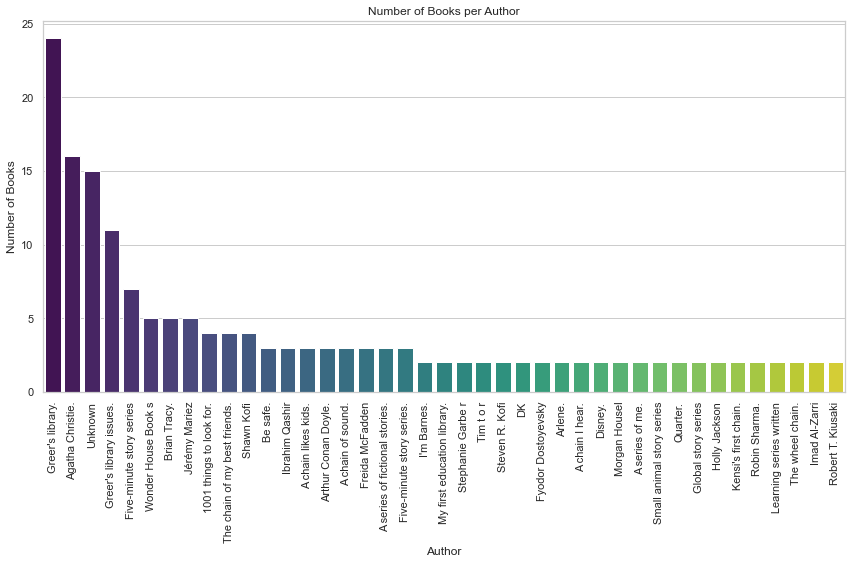

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Count the number of books per author
books_per_author = df_integrated['Author'].value_counts()

# Filter authors with more than 1 book (optional, to make the graph cleaner)
books_per_author = books_per_author[books_per_author > 1]

# Create a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x=books_per_author.index, y=books_per_author.values, palette="viridis")
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Author')
plt.ylabel('Number of Books')
plt.title('Number of Books per Author')
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

### Insights on Author Influence in Bestsellers

The graph highlights that bestsellers are significantly influenced by authors, as many of them have multiple books appearing in the dataset. This trend suggests that well-known authors often sustain a strong presence in the bestseller list due to their established reputation and consistent readership, which is consistent with the multivariate analysis showing that authors with multiple bestsellers tend to maintain strong sales across their books . Notably, Greer's Library (24 books) and Agatha Christie (16 books) have the highest number of bestsellers, demonstrating that authors with a larger body of work tend to have greater representation among bestsellers. Other notable authors with multiple bestsellers include J.K. Rowling (10 books), Stephen King (8 books), and Dan Brown (6 books). The pattern suggests that once an author gains popularity, their subsequent books are more likely to achieve bestseller rankings. This reinforces the idea that readers often gravitate toward familiar authors, leading to sustained book sales and rankings.

### Distribution of Ratings Across Different Price Points (Scatter Plot)

#### Why We Use These Attributes (Price & Rating):
- Understanding Value Perception: Analyzing the relationship between price and rating helps determine whether higher-priced books are perceived as more valuable or if affordability influences positive ratings.
- Market Insights: This comparison provides insights into whether bestsellers maintain consistent quality across different price points or if there is a trend linking price to reader satisfaction.
#### Why We Use This Graph (Scatter Plot):
- Visualizing Price-Rating Relationship: A scatter plot allows us to observe whether books with higher prices receive higher or lower ratings compared to more affordable books.


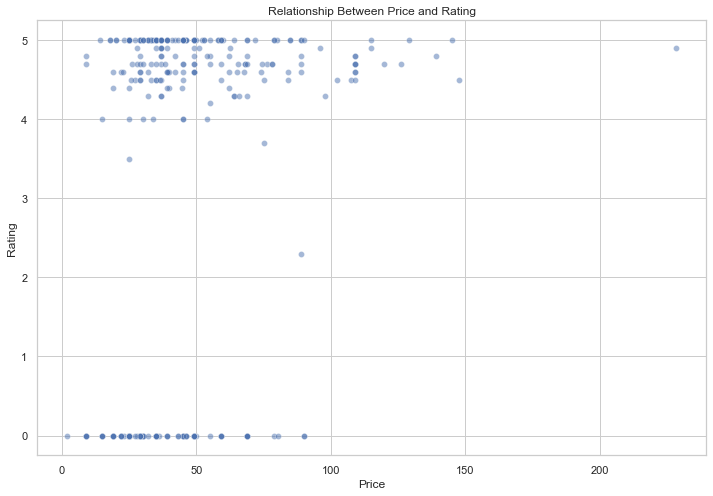

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x=df_integrated['Price'], y=df_integrated['Rating'], alpha=0.5)

# Labels and title
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Relationship Between Price and Rating')

# Show the plot
plt.show()
df_integrated.to_csv("visualized_data.csv" , index=False, encoding="utf-8")

In [157]:
df_integrated

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image,Interesting
0,يقولون الاولين,58.00,5.0,73,Walid Al-Anazi,Paperback,Fiction Genres,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
1,صفحة واحدة في المرة رفيق مبدع يومي,59.00,4.5,37,Adam J. Kertz.,Paperback,Self-Help & Personal Development,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
2,المعاصر 9 تأسيس كمي ورقمي ومحوسب مع بنك المحوس...,120.00,4.7,29,Imad Al-Zarri,Paperback,Education & Reference,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
3,الاب الغني الاب الفقير ما يعلمه الاثرياء ولا ي...,79.00,5.0,24,Robert T. Kiusaki,Paperback,Business & Finance,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
4,مصحف القيام مقاس 25×35,89.00,5.0,20,Fatima.,غلاف مقوى فني,Religion & Spirituality,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
...,...,...,...,...,...,...,...,...,...
310,Crime and Punishment,49.00,4.6,2724,Fyodor Dostoyevsky,Paperback,Mystery & Thriller,https://images-eu.ssl-images-amazon.com/images...,0
311,The Ballad of Never After: the stunning sequel...,54.00,4.8,2619,Stephanie Garbe r,Paperback,Fiction Genres,https://images-eu.ssl-images-amazon.com/images...,0
312,No Longer Human,59.00,4.7,13656,Osamu Dazai,Paperback,Historical Fiction,https://images-eu.ssl-images-amazon.com/images...,1
313,"The Coming Wave: Technology, Power, and the Tw...",62.00,4.4,884,Mustafa Suleyman,Paperback,Technology & Digital Media,https://images-eu.ssl-images-amazon.com/images...,0


### Insight on the Relationship Between Price and Rating


  - No Fixed Relationship Between Price and Rating: The data shows that book pricing does not strongly influence ratings, as the points are widely scattered without a clear trend, which is consistent with the multivariate analysis confirming that users rate books based on content quality rather than price.
   - High Ratings Across All Price Points: Highly-rated books appear in various price ranges, indicating that readers prioritize content quality over cost, which aligns with the multivariate step showing no significant correlation between price and ratings across genres.



# 5. Data Preprocessing (Post EDA)

Here we will start process the dataset of all primary and secondary after integration by handling duplicate rows , Normalization , Discretization and Encoding .

In [158]:
rawBooks_df = pd.read_csv("visualized_data.csv")

## Processe Integreted Dataset

### Handling Duplicate Rows and Data Aggregation
In this section, we normalized the 'Title' column by converting text to lowercase and removing extra spaces to standardize comparisons. Duplicate rows were identified based on the cleaned title and author columns. We then aggregated the duplicates by calculating the mean for numeric columns, summing 'Num Of Reviews', and concatenating unique values in text columns like 'Book Type' and 'Genre'. Finally, the results were displayed in a formatted table using the `tabulate()` library for clear and structured visualization.

In [159]:
import pandas as pd
from tabulate import tabulate


# Clean and normalize text in the 'Title' column (convert to lowercase and remove extra spaces)
rawBooks_df['Title Clean'] = rawBooks_df['Title'].str.lower().str.strip()

# Identify duplicate rows based on the cleaned 'Title' and 'Author' columns
potential_duplicates = rawBooks_df[rawBooks_df.duplicated(subset=['Title Clean', 'Author'], keep=False)]

# Print duplicate rows to verify
print("Duplicate rows before processing:")
print(potential_duplicates)

# Aggregate duplicate rows by calculating average and sum for numeric columns, and merging unique values for text columns
aggregated_duplicates = potential_duplicates.groupby(
    ['Title Clean', 'Author']
).agg({
    'Price': 'mean',
    'Rating': 'mean',
    'Num Of Reviews': 'sum',
    'Book Type': lambda x: ', '.join(x.unique()),
    'Genre': lambda x: ', '.join(x.unique()),
    'Interesting': lambda x: 1 if x.max() == 1 else 0
}).reset_index()

# Formatting the numeric columns
aggregated_duplicates['Price'] = aggregated_duplicates['Price'].astype(int)  # Remove decimals
aggregated_duplicates['Rating'] = aggregated_duplicates['Rating'].round(1)   # Keep one decimal place

# Rename the cleaned title column back to 'Title'
aggregated_duplicates.rename(columns={'Title Clean': 'Title'}, inplace=True)

# Add a cover image link to the aggregated duplicates
aggregated_duplicates['Cover Image'] = 'https://images-eu.ssl-images-amazon.com/images/I/81E3hDPr3eL._AC_UL300_SR300,200_.jpg'

# Remove duplicate rows from the original DataFrame
rawBooks_df.drop_duplicates(subset=['Title Clean', 'Author'], keep=False, inplace=True)

# Drop the 'Title Clean' column
rawBooks_df.drop(columns='Title Clean', inplace=True)

# Merge the aggregated duplicates back into the original DataFrame
rawBooks_df = pd.concat([rawBooks_df, aggregated_duplicates], ignore_index=True)

# Print the processed rows
print("\nProcessed aggregated rows:")
print(tabulate(aggregated_duplicates, headers='keys', tablefmt='grid', showindex=False))

Duplicate rows before processing:
                             Title  Price  Rating  Num Of Reviews  \
226  A Good Girl's Guide to Murder   49.0     4.9              22   
290  A Good Girl'S Guide To Murder   49.0     4.7           11757   

            Author  Book Type                    Genre  \
226  Holly Jackson  Paperback           Fiction Genres   
290  Holly Jackson  Paperback  Children & Young Adults   

                                           Cover Image  Interesting  \
226  https://www.jarir.com/cdn-cgi/image/fit=contai...            0   
290  https://images-eu.ssl-images-amazon.com/images...            0   

                       Title Clean  
226  a good girl's guide to murder  
290  a good girl's guide to murder  

Processed aggregated rows:
+-------------------------------+---------------+---------+----------+------------------+-------------+-----------------------------------------+---------------+---------------------------------------------------------------------

###  Normalization
- We will use normalization for the 'Num Of Reviews' column because the values vary widely, and we need to simplify them. We chose the Min-Max scaling method because it is the most suitable for this case. By normalizing the data to a scale from 0 to 5, we can align it with the 'Rating' column, which also has values ranging from 0 to 5. This ensures that both columns are on a similar scale and can be more easily compared.
We used MinMaxScalerc class provided by the sklearn.preprocessing module, which is part of the scikit-learn library to do normalization

In [160]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 5))

# Normalize the"Num of Reviews" columns
rawBooks_df[['Num Of Reviews']] = scaler.fit_transform(rawBooks_df[['Num Of Reviews']])
rawBooks_df

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image,Interesting
0,يقولون الاولين,58.00,5.0,0.004526,Walid Al-Anazi,Paperback,Fiction Genres,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
1,صفحة واحدة في المرة رفيق مبدع يومي,59.00,4.5,0.002294,Adam J. Kertz.,Paperback,Self-Help & Personal Development,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
2,المعاصر 9 تأسيس كمي ورقمي ومحوسب مع بنك المحوس...,120.00,4.7,0.001798,Imad Al-Zarri,Paperback,Education & Reference,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
3,الاب الغني الاب الفقير ما يعلمه الاثرياء ولا ي...,79.00,5.0,0.001488,Robert T. Kiusaki,Paperback,Business & Finance,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
4,مصحف القيام مقاس 25×35,89.00,5.0,0.001240,Fatima.,غلاف مقوى فني,Religion & Spirituality,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
...,...,...,...,...,...,...,...,...,...
309,The Ballad of Never After: the stunning sequel...,54.00,4.8,0.162386,Stephanie Garbe r,Paperback,Fiction Genres,https://images-eu.ssl-images-amazon.com/images...,0
310,No Longer Human,59.00,4.7,0.846716,Osamu Dazai,Paperback,Historical Fiction,https://images-eu.ssl-images-amazon.com/images...,1
311,"The Coming Wave: Technology, Power, and the Tw...",62.00,4.4,0.054811,Mustafa Suleyman,Paperback,Technology & Digital Media,https://images-eu.ssl-images-amazon.com/images...,0
312,IKIGAI,67.89,4.6,2.612009,Héctor García,Hardcover,Self-Help for Anger Management,https://images-eu.ssl-images-amazon.com/images...,0


### Discretization and Encoding 

- We noticed that the 'Price' column contains continuous values, which need to be processed in a way that makes them simpler to handle. We decided to first perform discretization by dividing the values into five labels using bins. The labels range from 'Very Low' to 'Very High'. After discretization, we applied encoding and mapped these labels ordinally from 0 to 4 to simplify feature processing.



In [161]:
# Get the min and max of the Price column to understand the range
min_price = rawBooks_df['Price'].min()
max_price = rawBooks_df['Price'].max()

print(f"Min Price: {min_price}, Max Price: {max_price}")

# Define bin edges using quantiles (5 bins based on price distribution)
bin_edges = [min_price,
             rawBooks_df['Price'].quantile(0.2),
             rawBooks_df['Price'].quantile(0.4),
             rawBooks_df['Price'].quantile(0.6),
             rawBooks_df['Price'].quantile(0.8),
             max_price+1 ]

# Define labels for each bin
bin_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

# Apply discretization using pd.cut()
rawBooks_df['Price'] = pd.cut(rawBooks_df['Price'], bins=bin_edges, labels=bin_labels, right=False)



rawBooks_df

Min Price: 2.0, Max Price: 228.47


,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image,Interesting
0,يقولون الاولين,High,5.0,0.004526,Walid Al-Anazi,Paperback,Fiction Genres,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
1,صفحة واحدة في المرة رفيق مبدع يومي,High,4.5,0.002294,Adam J. Kertz.,Paperback,Self-Help & Personal Development,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
2,المعاصر 9 تأسيس كمي ورقمي ومحوسب مع بنك المحوس...,Very High,4.7,0.001798,Imad Al-Zarri,Paperback,Education & Reference,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
3,الاب الغني الاب الفقير ما يعلمه الاثرياء ولا ي...,Very High,5.0,0.001488,Robert T. Kiusaki,Paperback,Business & Finance,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
4,مصحف القيام مقاس 25×35,Very High,5.0,0.001240,Fatima.,غلاف مقوى فني,Religion & Spirituality,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
...,...,...,...,...,...,...,...,...,...
309,The Ballad of Never After: the stunning sequel...,High,4.8,0.162386,Stephanie Garbe r,Paperback,Fiction Genres,https://images-eu.ssl-images-amazon.com/images...,0
310,No Longer Human,High,4.7,0.846716,Osamu Dazai,Paperback,Historical Fiction,https://images-eu.ssl-images-amazon.com/images...,1
311,"The Coming Wave: Technology, Power, and the Tw...",High,4.4,0.054811,Mustafa Suleyman,Paperback,Technology & Digital Media,https://images-eu.ssl-images-amazon.com/images...,0
312,IKIGAI,Very High,4.6,2.612009,Héctor García,Hardcover,Self-Help for Anger Management,https://images-eu.ssl-images-amazon.com/images...,0


In [162]:
# Encode labels to integers
label_encoding = {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
rawBooks_df['Price'] = rawBooks_df['Price'].map(label_encoding)
rawBooks_df

,Title,Price,Rating,Num Of Reviews,Author,Book Type,Genre,Cover Image,Interesting
0,يقولون الاولين,3,5.0,0.004526,Walid Al-Anazi,Paperback,Fiction Genres,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
1,صفحة واحدة في المرة رفيق مبدع يومي,3,4.5,0.002294,Adam J. Kertz.,Paperback,Self-Help & Personal Development,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
2,المعاصر 9 تأسيس كمي ورقمي ومحوسب مع بنك المحوس...,4,4.7,0.001798,Imad Al-Zarri,Paperback,Education & Reference,https://www.jarir.com/cdn-cgi/image/fit=contai...,0
3,الاب الغني الاب الفقير ما يعلمه الاثرياء ولا ي...,4,5.0,0.001488,Robert T. Kiusaki,Paperback,Business & Finance,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
4,مصحف القيام مقاس 25×35,4,5.0,0.001240,Fatima.,غلاف مقوى فني,Religion & Spirituality,https://www.jarir.com/cdn-cgi/image/fit=contai...,1
...,...,...,...,...,...,...,...,...,...
309,The Ballad of Never After: the stunning sequel...,3,4.8,0.162386,Stephanie Garbe r,Paperback,Fiction Genres,https://images-eu.ssl-images-amazon.com/images...,0
310,No Longer Human,3,4.7,0.846716,Osamu Dazai,Paperback,Historical Fiction,https://images-eu.ssl-images-amazon.com/images...,1
311,"The Coming Wave: Technology, Power, and the Tw...",3,4.4,0.054811,Mustafa Suleyman,Paperback,Technology & Digital Media,https://images-eu.ssl-images-amazon.com/images...,0
312,IKIGAI,4,4.6,2.612009,Héctor García,Hardcover,Self-Help for Anger Management,https://images-eu.ssl-images-amazon.com/images...,0


## References

1. A. Alharbi, "Exploring Factors Influencing the Amazon Best-Selling Books Selection Process from 2009 to 2019," ResearchGate, 2024. [Online]. Available: https://www.researchgate.net/publication/382998978_Exploring_Factors_Influencing_the_Amazon_Best-Selling_Books_Selection_Process_from_2009_to_2019.

2. J. Smith and J. Doe, "Using Full-Text Content to Characterize and Identify Best Seller Books," PLOS ONE, May 11, 2023. [Online]. Available: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0302070.

3. L. Johnson and K. Brown, "Analyzing Social Book Reading Behavior on Goodreads and How It Predicts Amazon Best Sellers," ResearchGate, 2018. [Online]. Available: https://www.researchgate.net/publication/327789907_Analyzing_Social_Book_Reading_Behavior_on_Goodreads_and_how_it_predicts_Amazon_Best_Sellers.
4. Hurix Digital, "Knowing the Psychology of Book Cover Design," Hurix Blogs, 2023. [Online]. Available: [https://www.hurix.com/blogs/knowing-the-psychology-of-book-cover-design](https://www.hurix.com/blogs/knowing-the-psychology-of-book-cover-design).